# 09. Pressures I: Losses and Negatives

**The question.** Which training pressure earns its place — and how many seeds does an
answer even need? This notebook opens the TRAINING-PRESSURES arc, where the lab's working
hypothesis lives or dies: every training design choice is a pre-registered conjecture
(*this pressure moves this embedding property, which moves this system metric*), and this
is the first notebook where encoders actually train. Before any loss family can "win",
the lab needs the instrument that says whether a win is real: **MET-04**, the variance
decomposition and power table that PLAN §3 makes the *binding arbiter* for every
mid/node training matrix.

**What this notebook settles.** Three things, in dependency order. (1) **MET-04 pilot**:
a 3-seed × 2-noise-draw grid at one fixed training configuration, decomposed into
variance components, becomes `met04_power_table` — how many replicates a delta of
0.01 / 0.02 / 0.05 B³F1 actually needs. (2) **TRN-01 smoke slice**: the four contrastive
loss families {InfoNCE, SupCon, triplet, CoSENT} at *identical optimizer-step budget*
(asserted from the training history, never assumed), each scored by one shared
system-metric recipe plus the invariance battery and the geometry panel — and the verdict
read **through the MET-04 lens**: a single-seed ranking whose margins sit inside the
measured replicate sigma is noise, and saying so is the finding. (3) **TRN-02 smoke
slice**: the false-negative-contamination trap of hard-negative mining in a dedup-dense
corpus — contamination *measured* at every re-mining from the loop history, dialed
across residual-duplication levels, and the cluster-aware filter's recovery tested,
oracle vs a deployable soundex proxy.

**Scope honesty, up front.** Everything trained here is the smoke-tier scratch char/byte
encoder (pretrained-subword arms are `# [RUN-IN-TARGET mac]` — huggingface.co is blocked
from this container, `notes/COMPAT.md`). Single-seed matrix rows are DEMONSTRATIONS of
machinery; the definitive multi-seed matrices are tier=mid/node, and every verdict below
says so explicitly. No entity appears on both sides of any train/eval boundary
(entity-disjoint splits from `met07_splits`, PLAN §5).

In [1]:
import copy
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display

from er_lab.blocking import ann
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import NON_TEXT_ROLES, ROLES
from er_lab.eval.bootstrap import bootstrap_ci
from er_lab.eval.operating_points import find_threshold_for_precision
from er_lab.eval.power import power_table, variance_components
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.noise.channels import (
    field_dropout,
    hub_value,
    load_lexicon,
    name_order_swap,
    nickname,
    typo,
)
from er_lab.noise.generate import generate_corpus
from er_lab.probes.battery import battery_report, build_probe_set
from er_lab.probes.geometry import alignment, hubness, rankme, uniformity
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.serialize import serialize_frame, serialize_record
from er_lab.train.loop import train_encoder
from er_lab.train.mining import (
    ann_hard_negatives,
    bm25_hard_negatives,
    build_pairs_inbatch,
    cluster_aware_filter,
    fn_contamination,
)

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v21-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants — and the one budget rule every arm obeys

**Budget-matching is step-count accounting** (PLAN §3.1): "matched budget" means the
*exact same number of optimizer steps* in every compared arm, asserted from the returned
training history — never epochs, never wall-clock, never trust. The dials below scale the
*sizes* (training-slice records, eval-slice records, probe counts, bootstrap replicates)
with tier; the *protocol* (precision-0.99 operating point, entity-unit BCa CIs,
entity-disjoint splits) is identical at every tier. Encoder shape is also tier-scaled:
the smoke encoder is deliberately tiny (dim 128, 2 layers, 4 heads, max_len 128 bytes) so
fifteen budget-matched training runs fit a 4-CPU container. Smoke budget for the whole
notebook: **<= ~30 min on the 4-CPU container** (measured per section and printed at the
end; this is the series' heaviest smoke notebook — it trains 15 encoders).

In [3]:
TIER = str(cfg.run.tier)
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
SIZES = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}  # train records
EVAL_N = {"smoke": 5_000, "mid": None, "target": None, "analytical": 5_000}  # eval records
GRID = {"smoke": 40, "mid": 150, "target": 200, "analytical": 40}[TIER]
N_BOOT = {"smoke": 400, "mid": 1000, "target": 2000, "analytical": 400}[TIER]
PROBE_N = {"smoke": 120, "mid": 400, "target": 800, "analytical": 120}[TIER]
TRUE_PAIR_N = {"smoke": 300, "mid": 1000, "target": 2000, "analytical": 300}[TIER]
GEO_N = {"smoke": 1_500, "mid": 4_000, "target": 8_000, "analytical": 1_500}[TIER]
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
REMINE_EVERY = 50  # re-mine cadence (steps) for mining arms: contamination is re-MEASURED too
PREC_TARGET = 0.99  # PLAN §5 primary fixed entity-precision operating point
CAND_K = 10  # eval candidate budget: ann.candidates(k=10, index='flat')
ENC_BATCH = 256  # inference encode batch
PRIMARY_SEED = int(cfg.run.seed)
PILOT_SEEDS = [int(s) for s in cfg.run.seeds]  # MET-04 seed factor levels
NOISE_DRAW_SEEDS = {"smoke": (201, 202), "mid": (201, 202, 203)}.get(TIER, (201, 202))
BOOST_DUP = {"a": 1.5, "max": 12}  # TRN-02 high-duplication regeneration (documented params)
NATURAL_DUP = {"a": 2.5, "max": 20}  # the calibrated corpus's own dup distribution (NB05)

# Budget-matched encoder + step budget, set through the typed cfg keys so the config hash
# on every registered artifact records exactly what trained.
cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
MINER_K = int(cfg.train.miner_k)
print(f"tier={TIER}: steps={STEPS} batch={BATCH} model=(dim {cfg.model.dim}, "
      f"layers {cfg.model.layers}, heads {cfg.model.heads}, max_len {cfg.model.max_len}); "
      f"train-slice budget {SIZES[TIER]}, eval-slice budget {EVAL_N[TIER]}, grid={GRID}, "
      f"n_boot={N_BOOT}, miner_k={MINER_K}, re-mine every {REMINE_EVERY} steps")
print(f"MET-04 pilot: seeds {PILOT_SEEDS} x noise-draw seeds {list(NOISE_DRAW_SEEDS)}; "
      "smoke budget <= ~30 min")

tier=smoke: steps=250 batch=64 model=(dim 128, layers 2, heads 4, max_len 128); train-slice budget 3000, eval-slice budget 5000, grid=40, n_boot=400, miner_k=10, re-mine every 50 steps
MET-04 pilot: seeds [17, 23, 29] x noise-draw seeds [201, 202]; smoke budget <= ~30 min


## 1. The arena, and the one recipe every encoder is judged by

Both inputs load through the registry at this run's tier: the calibrated corpus
(notebook 05 — noise channels at NSE-01-measured rates, household confusables, hub
values) and the MET-07 splits. Training uses the **entity-disjoint train half**,
subsampled *entity-complete* (whole clusters, never split); evaluation uses a fixed
entity-complete subsample of the **eval half**. One deliberate consequence of the
corpus's provenance: `historical_50k` natively carries many records per person *before*
notebook 05 adds calibrated duplicates, so residual duplication here is high — which is
exactly the regime where TRN-02's mining trap bites hardest.

**The shared system-metric recipe** (one helper, used verbatim for every trained encoder
in this notebook and re-usable downstream): serialize the eval slice per `cfg.serialize`
→ encode → `ann.candidates(k=10, index='flat')` → cosine scores mapped to [0, 1] →
`find_threshold_for_precision` at the locked 0.99 entity-precision point (with the
PLAN §5 **loud fallback** when a smoke-sized eval set cannot reach it — never a silent
protocol switch) → transitive closure → B-cubed with **entity-unit BCa CIs** (MET-03's
coverage-validated unit). If any arm were scored by its own recipe, the comparison would
be about recipes; this helper is the rail against that.

In [4]:
t_sec = time.time()
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
splits, splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
print(f"split scheme: {SCHEME} (seed {splits['metadata']['seed']}, "
      f"entities straddling the boundary: {straddle})")
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"


def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same helper as notebook 05 §6; still notebook-local — a shared home in
    er_lab.data would serve, reported as a package gap.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


def dup_profile(frame: pd.DataFrame) -> dict:
    """Residual-duplication descriptors of a corpus slice (TRN-02's x-axis)."""
    sizes = frame["entity_id"].value_counts()
    n = len(frame)
    return {
        "n_records": int(n),
        "n_entities": int(frame["entity_id"].nunique()),
        "mean_cluster_size": float(n / frame["entity_id"].nunique()),
        "dup_record_share": float(frame["entity_id"].map(sizes).ge(2).mean()),
        "within_pairs_per_record": float((sizes * (sizes - 1) / 2).sum() / n),
    }


train_slice = entity_complete_subsample(
    train_full, SIZES[TIER], np.random.default_rng(PRIMARY_SEED)
)
ev_slice = entity_complete_subsample(
    eval_full, EVAL_N[TIER], np.random.default_rng(PRIMARY_SEED + 1)
)
prof_train, prof_ev = dup_profile(train_slice), dup_profile(ev_slice)
print(f"train slice: {prof_train['n_records']:,} records / {prof_train['n_entities']:,} "
      f"entities (mean cluster {prof_train['mean_cluster_size']:.1f})")
print(f"eval  slice: {prof_ev['n_records']:,} records / {prof_ev['n_entities']:,} entities "
      f"(mean cluster {prof_ev['mean_cluster_size']:.1f}) — fixed across ALL arms (paired)")

corpus: calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities
split scheme: entity_disjoint (seed 17, entities straddling the boundary: 0)
train slice: 3,010 records / 222 entities (mean cluster 13.6)
eval  slice: 5,006 records / 393 entities (mean cluster 12.7) — fixed across ALL arms (paired)


In [5]:
# Serialization: per cfg.serialize, through the same role rule the training loop uses.
TEXT_ROLES = [c for c in corpus.columns if c in ROLES and c not in NON_TEXT_ROLES]
SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)


def texts_of(frame: pd.DataFrame) -> list[str]:
    return serialize_frame(
        frame, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
    ).tolist()


EVAL_TEXTS = texts_of(ev_slice)
TRUTH_EV = ev_slice.set_index("record_id")["entity_id"]
RECORDS_EV = pd.Index(TRUTH_EV.index)
EVAL_POS = {rid: i for i, rid in enumerate(ev_slice["record_id"].astype(str))}
lens = np.array([len(t.encode("utf-8")) for t in EVAL_TEXTS])
share_trunc = float((lens > cfg.model.max_len - 1).mean())
print(f"serialization: scheme={SER_SCHEME} missing={SER_MISSING}, roles={TEXT_ROLES}")
print(f"eval text length: median {int(np.median(lens))} bytes; {share_trunc:.0%} exceed the "
      f"encoder's max_len={cfg.model.max_len} byte window and are TRUNCATED — at smoke the "
      "tail roles (zip/sex, sometimes city) are often invisible to the encoder. A real "
      "smoke-tier constraint, carried into every battery reading below; the mid-tier "
      "window (192) covers the full row.")


def fresh_encoder(seed: int):
    """Deterministic encoder init: same seed => identical starting weights."""
    set_all_seeds(seed)
    return build_encoder(cfg)


def train_arm(corpus_df, *, loss, miner, seed, eval_every=0, filter_proxy=None, encoder=None):
    """One budget-matched training run; asserts the step budget from the history."""
    enc = fresh_encoder(seed) if encoder is None else encoder
    t0 = time.time()
    enc, hist = train_encoder(
        enc, corpus_df, cfg, loss_name=loss, miner_name=miner, augment_kind="none",
        steps=STEPS, eval_every=eval_every, filter_proxy=filter_proxy, seed=seed,
    )
    secs = time.time() - t0
    assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
        f"budget violation: expected exactly {STEPS} optimizer steps, "
        f"history shows {len(hist)}"
    )
    return enc, hist, secs


def system_metric(encoder, *, label: str, with_ci: bool = True) -> dict:
    """THE shared recipe (module docstring above): every encoder answers the same question."""
    t0 = time.time()
    emb = encoder.encode(EVAL_TEXTS, batch_size=ENC_BATCH)
    cand = ann.candidates(ev_slice, emb, k=CAND_K, index="flat")
    ia = cand["a"].astype(str).map(EVAL_POS).to_numpy()
    ib = cand["b"].astype(str).map(EVAL_POS).to_numpy()
    cos = np.einsum("ij,ij->i", emb[ia], emb[ib])
    scored = pd.DataFrame({"a": cand["a"], "b": cand["b"],
                           "prob": np.clip((cos + 1.0) / 2.0, 0.0, 1.0)})
    cache: dict[float, pd.Series] = {}

    def clusterer(t: float) -> pd.Series:
        if t not in cache:
            cache[t] = transitive_closure(scored, threshold=float(t), records=RECORDS_EV)
        return cache[t]

    res = find_threshold_for_precision(
        scored.rename(columns={"prob": "score"}), clusterer, TRUTH_EV,
        target=PREC_TARGET, grid=GRID,
    )
    if not res["attained"]:
        print(f"  !! [{label}] precision {PREC_TARGET} UNATTAINABLE on this eval slice — "
              f"reporting the highest-attainable point P={res['attained_precision']:.4f} "
              f"(fallback='{res['fallback']}'; PLAN §5 rail: loud, never silent)")
    row = {
        "threshold": res["threshold"], "attained": bool(res["attained"]),
        "attained_precision": res["attained_precision"], "recall_at": res["recall_at"],
        "f1": res["f1_at"], "n_candidate_pairs": len(scored),
    }
    if with_ci:
        pred = clusterer(res["threshold"])
        ci = bootstrap_ci(pred, TRUTH_EV, "bcubed_f1", unit="entity", n_boot=N_BOOT,
                          seed=PRIMARY_SEED)
        row["f1_lo"], row["f1_hi"] = ci["ci_low"], ci["ci_high"]
    row["eval_secs"] = time.time() - t0
    return row


tick("§1 arena + shared recipe", t_sec)

serialization: scheme=colval missing=token, roles=['full_name', 'given_name', 'family_name', 'dob', 'city', 'zip', 'sex']
eval text length: median 199 bytes; 100% exceed the encoder's max_len=128 byte window and are TRUNCATED — at smoke the tail roles (zip/sex, sometimes city) are often invisible to the encoder. A real smoke-tier constraint, carried into every battery reading below; the mid-tier window (192) covers the full row.
[section timing] §1 arena + shared recipe: 0s


### The property instruments: battery and geometry, shared too

The other half of every conjecture is the **embedding property**. One probe set
(notebook-08 battery vocabulary: typo dial + nickname/format `should_hold` slices,
birth-year/twin `must_not_hold` confusables) and one geometry panel
(Wang–Isola alignment/uniformity, RankMe effective rank, hubness skew) are built ONCE on
the eval slice and measured under each trained encoder — same probes, same true-pair
reference, so property deltas between arms are about the arms. The nickname lexicon is
the fetched carltonnorthern table with notebook 04's sanitization workaround
(upstream format drift; falls back to the channel's built-in mini-lexicon if the fetch
artifact is absent). Note `field_order_permutation` is empty by construction — colval
serialization is order-fixed — and that emptiness is information, not an error.

In [6]:
t_sec = time.time()
try:
    _lex_raw = load_lexicon(str(REPO_ROOT / "data"))
    LEXICON = {
        c: {v for v in vs if v not in ("has_nickname", "relationship")}
        for c, vs in _lex_raw.items() if c != "name1"
    }
    LEXICON = {c: v for c, v in LEXICON.items() if v} or None
    lex_note = f"carltonnorthern lexicon, sanitized (NB04 workaround): {len(LEXICON or {})} names"
except FileNotFoundError:
    LEXICON = None
    lex_note = "lexicon file absent -> nickname channel built-in mini-lexicon"
print(lex_note)


def probe_serialize(row: dict) -> str:
    return serialize_record(row, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING)


PROBES = build_probe_set(
    ev_slice, serialize=probe_serialize, seed=PRIMARY_SEED, lexicon=LEXICON,
    n_per_slice=PROBE_N,
)
print("probe slices built:")
display(PROBES.groupby(["kind", "slice"]).size().rename("n_pairs").to_frame())

_tp = build_pairs_inbatch(ev_slice, n_pairs=TRUE_PAIR_N, seed=PRIMARY_SEED)
_etext = pd.Series(EVAL_TEXTS, index=ev_slice["record_id"].astype(str))
TRUE_PAIRS_TXT = pd.DataFrame({
    "text_a": _etext.loc[_tp["a_id"]].to_numpy(),
    "text_b": _etext.loc[_tp["b_id"]].to_numpy(),
})
_rng_geo = np.random.default_rng(PRIMARY_SEED + 7)
_geo_pos = np.sort(_rng_geo.choice(len(ev_slice), size=min(GEO_N, len(ev_slice)),
                                   replace=False))
GEO_TEXTS = [EVAL_TEXTS[i] for i in _geo_pos]
_rid_geo = ev_slice["record_id"].astype(str).iloc[_geo_pos]
GEO_KIND = np.where(
    _rid_geo.str.contains("#dup"), "generated_duplicate",
    np.where(_rid_geo.str.contains("#hh1"), "household_confusable", "base_record"),
)
print(f"true-pair reference: {len(TRUE_PAIRS_TXT)} same-entity eval pairs; "
      f"geometry sample: {len(GEO_TEXTS)} records "
      f"({pd.Series(GEO_KIND).value_counts().to_dict()})")


def property_panel(encoder) -> tuple[pd.DataFrame, dict, np.ndarray]:
    """Battery report + geometry numbers + the geometry-sample embeddings, one encoder."""

    def encode_fn(ts):
        return encoder.encode(list(ts), batch_size=ENC_BATCH)

    rep = battery_report(encode_fn, PROBES, true_pairs=TRUE_PAIRS_TXT)
    emb_a = encode_fn(TRUE_PAIRS_TXT["text_a"].tolist())
    emb_b = encode_fn(TRUE_PAIRS_TXT["text_b"].tolist())
    geo_emb = encode_fn(GEO_TEXTS)
    hub = hubness(geo_emb, k=10)
    geo = {
        "align": alignment(emb_a, emb_b),
        "uniform": uniformity(geo_emb),
        "rankme": rankme(geo_emb),
        "hub_skew": hub["skewness"],
    }
    return rep, geo, geo_emb


def pca2(emb: np.ndarray) -> np.ndarray:
    """First two principal components — the triptych's geometry scatter coordinates."""
    x = np.asarray(emb, dtype=np.float64)
    x = x - x.mean(axis=0)
    _u, _s, vt = np.linalg.svd(x, full_matrices=False)
    return x @ vt[:2].T


tick("§1b property instruments", t_sec)

carltonnorthern lexicon, sanitized (NB04 workaround): 1232 names


probe slices built:


n_pairs
kind          slice                        
must_not_hold different_birth_year       94
              twin_household            120
should_hold   format_drift               91
              nickname_swap              85
              typo@0.02                 120
              typo@0.05                 120
              typo@0.1                  120
              typo@0.2                  120

true-pair reference: 300 same-entity eval pairs; geometry sample: 1500 records ({'base_record': 826, 'generated_duplicate': 635, 'household_confusable': 39})
[section timing] §1b property instruments: 38s


## 2. Three conjectures, before any encoder exists

All three cards render (and register, immutably) *now* — before a single training step —
per PLAN §5. Note what each card pre-registers beyond a direction: MET-04 states a
quantitative variance floor; TRN-01 and TRN-02 pre-register **the decision rule** that a
smoke margin only counts beyond the MET-04 single-seed detectability bar, so the honest
"it's noise" outcome is a scored outcome, not a shrug. And per PLAN §5's adoption-gate
vs mediation distinction: nothing below ever presents two marginal effects as mediation
— mediation claims need arms × seeds × draws that only the node grid has.

In [7]:
_ = conjecture_card(
    card_id="MET-04",
    conjecture=(
        "At smoke scale, run-to-run variance from training seed and corpus noise draw is "
        "comparable to the between-arm deltas the TRN matrices are trying to detect, so a "
        "single-seed smoke ranking of training pressures is unstable — replicate counts "
        "must be sized from a measured variance decomposition, not assumed."
    ),
    pressure=(
        "replicate identity, not a training design: the training seed (encoder init + "
        "batch/augmentation stream) and the corpus noise draw (regeneration seed of the "
        "training slice through the calibrated channel set), crossed 3 x 2 at one fixed "
        "configuration (infonce / in-batch / no augmentation, scratch-char encoder, "
        "matched step budget)"
    ),
    property=(
        "variance components sigma2_seed, sigma2_noise_draw and residual from the "
        "method-of-moments decomposition (er_lab.eval.power.variance_components) of the "
        "pilot grid's system metric"
    ),
    metric=(
        "B-cubed F1 on the entity-disjoint eval slice at the precision-0.99 operating "
        "point (loud highest-attainable fallback per PLAN section 5), one shared recipe "
        "for every run; the deliverable is the power table (seeds_needed at target deltas "
        "0.01 / 0.02 / 0.05, achieved power at n = 3/5/10)"
    ),
    prediction=(
        "sd_replicate = sqrt(sigma2_seed + sigma2_noise_draw) >= 0.01 absolute B-cubed "
        "F1, so a true between-arm delta of 0.01 needs more than 5 replicates at "
        "alpha=0.05 / power 0.8 while a delta of 0.05 needs roughly 5 or fewer; the seed "
        "component does not collapse to zero. Scope: a smoke pilot over the train-time "
        "factors only (split and eval-sampling components are the mid-tier "
        "decomposition's job) — this table binds smoke verdicts now and is superseded by "
        "the mid-tier table."
    ),
    registry=registry,
)

### Conjecture card `MET-04`

| | |
|---|---|
| **Conjecture** | At smoke scale, run-to-run variance from training seed and corpus noise draw is comparable to the between-arm deltas the TRN matrices are trying to detect, so a single-seed smoke ranking of training pressures is unstable — replicate counts must be sized from a measured variance decomposition, not assumed. |
| **Pressure (dial)** | replicate identity, not a training design: the training seed (encoder init + batch/augmentation stream) and the corpus noise draw (regeneration seed of the training slice through the calibrated channel set), crossed 3 x 2 at one fixed configuration (infonce / in-batch / no augmentation, scratch-char encoder, matched step budget) |
| **Embedding property** | variance components sigma2_seed, sigma2_noise_draw and residual from the method-of-moments decomposition (er_lab.eval.power.variance_components) of the pilot grid's system metric |
| **System metric** | B-cubed F1 on the entity-disjoint eval slice at the precision-0.99 operating point (loud highest-attainable fallback per PLAN section 5), one shared recipe for every run; the deliverable is the power table (seeds_needed at target deltas 0.01 / 0.02 / 0.05, achieved power at n = 3/5/10) |
| **Pre-registered prediction** | sd_replicate = sqrt(sigma2_seed + sigma2_noise_draw) >= 0.01 absolute B-cubed F1, so a true between-arm delta of 0.01 needs more than 5 replicates at alpha=0.05 / power 0.8 while a delta of 0.05 needs roughly 5 or fewer; the seed component does not collapse to zero. Scope: a smoke pilot over the train-time factors only (split and eval-sampling components are the mid-tier decomposition's job) — this table binds smoke verdicts now and is superseded by the mid-tier table. |

*Immutable — sha256 `98380156d047`; registered before the affected runs, never edited (PLAN §5).*


In [8]:
_ = conjecture_card(
    card_id="TRN-01",
    conjecture=(
        "In a dedup-dense person corpus, the contrastive loss family is a real design "
        "pressure at matched optimizer-step budget: losses that exploit entity-level "
        "supervision beyond a single positive pair (SupCon) align same-person records "
        "harder without collapsing the space, and that shows up in the system metric."
    ),
    pressure=(
        "loss family {InfoNCE, SupCon, triplet, CoSENT} with everything else locked: "
        "in-batch negatives, no augmentation, colval serialization, identical scratch-char "
        "encoder and init seed, identical optimizer-step count (asserted from the returned "
        "training history); the pretrained-subword regime completes the 8-cell factorial "
        "at mid/target"
    ),
    property=(
        "Wang-Isola alignment on held-out same-entity pairs (lower = tighter positives), "
        "with uniformity / RankMe / hubness as collapse guards, plus the invariance "
        "battery's typo-dial should-hold cosines"
    ),
    metric=(
        "B-cubed F1 with entity-unit BCa 95% CI on the entity-disjoint eval slice at the "
        "precision-0.99 operating point (loud fallback rail)"
    ),
    prediction=(
        "SupCon posts the best B-cubed F1 of the four and the lowest (best) alignment "
        "without the worst uniformity; explicit-negative losses (triplet, CoSENT) do not "
        "beat it at this budget. Decision rule, pre-registered: the smoke ranking counts "
        "only where the winning margin exceeds the single-seed detectability bar "
        "2*sqrt(2)*sd_replicate from the MET-04 pilot; a smaller margin means the smoke "
        "slice is noise-bound and the verdict is UNEXPLAINED pending the multi-seed node "
        "grid. Mediation (loss -> alignment -> F1) is not claimable from one seed and is "
        "not claimed."
    ),
    registry=registry,
)

### Conjecture card `TRN-01`

| | |
|---|---|
| **Conjecture** | In a dedup-dense person corpus, the contrastive loss family is a real design pressure at matched optimizer-step budget: losses that exploit entity-level supervision beyond a single positive pair (SupCon) align same-person records harder without collapsing the space, and that shows up in the system metric. |
| **Pressure (dial)** | loss family {InfoNCE, SupCon, triplet, CoSENT} with everything else locked: in-batch negatives, no augmentation, colval serialization, identical scratch-char encoder and init seed, identical optimizer-step count (asserted from the returned training history); the pretrained-subword regime completes the 8-cell factorial at mid/target |
| **Embedding property** | Wang-Isola alignment on held-out same-entity pairs (lower = tighter positives), with uniformity / RankMe / hubness as collapse guards, plus the invariance battery's typo-dial should-hold cosines |
| **System metric** | B-cubed F1 with entity-unit BCa 95% CI on the entity-disjoint eval slice at the precision-0.99 operating point (loud fallback rail) |
| **Pre-registered prediction** | SupCon posts the best B-cubed F1 of the four and the lowest (best) alignment without the worst uniformity; explicit-negative losses (triplet, CoSENT) do not beat it at this budget. Decision rule, pre-registered: the smoke ranking counts only where the winning margin exceeds the single-seed detectability bar 2*sqrt(2)*sd_replicate from the MET-04 pilot; a smaller margin means the smoke slice is noise-bound and the verdict is UNEXPLAINED pending the multi-seed node grid. Mediation (loss -> alignment -> F1) is not claimable from one seed and is not claimed. |

*Immutable — sha256 `761ef1a1ae05`; registered before the affected runs, never edited (PLAN §5).*


In [9]:
_ = conjecture_card(
    card_id="TRN-02",
    conjecture=(
        "Hard-negative mining in a dedup-dense corpus poisons itself: the harder the "
        "miner works, the more of its 'negatives' are unlabeled true duplicates (false "
        "negatives), the more so the higher the residual duplication — and a "
        "cluster-aware filter that drops mined pairs co-clustered by a truth proxy "
        "recovers most of what contamination costs."
    ),
    pressure=(
        "negative miner {in-batch, BM25-mined, ANN-mined, ANN + cluster-aware filter} at "
        "the calibrated corpus's natural duplication, plus ANN at a regenerated "
        "high-duplication variant (noise.generate dup boost, documented params), and one "
        "deployable-proxy filter demonstration (soundex(family_name) instead of oracle "
        "entity_id); loss fixed at InfoNCE, matched step budget"
    ),
    property=(
        "measured FN-contamination of the raw mined negative table "
        "(er_lab.train.mining.fn_contamination, logged in the training history at every "
        "re-mining) as a function of residual duplication, plus post-filter contamination "
        "and filter keep-rate"
    ),
    metric=(
        "B-cubed F1 with entity-unit BCa 95% CI on the entity-disjoint eval slice at the "
        "precision-0.99 operating point"
    ),
    prediction=(
        "P1: raw mined contamination rises monotonically with residual duplication "
        "(per-entity-cap dial through the natural corpus up to the boosted variant). "
        "P2: at natural duplication the unfiltered mined arms do not beat in-batch, and "
        "the oracle filter arm is the best mined arm. P3: the oracle filter recovers at "
        "least half of the in-batch-minus-ANN gap where that gap exists; the soundex "
        "proxy keeps most of the oracle's recovery while over-filtering some clean "
        "negatives. Decision rule: P1 is scored on the measured dial directly; P2/P3 "
        "system-metric claims are scored only beyond the MET-04 bar "
        "2*sqrt(2)*sd_replicate — inside the bar they are noise-bound (UNEXPLAINED), "
        "which at one smoke seed is the expected outcome."
    ),
    registry=registry,
)

### Conjecture card `TRN-02`

| | |
|---|---|
| **Conjecture** | Hard-negative mining in a dedup-dense corpus poisons itself: the harder the miner works, the more of its 'negatives' are unlabeled true duplicates (false negatives), the more so the higher the residual duplication — and a cluster-aware filter that drops mined pairs co-clustered by a truth proxy recovers most of what contamination costs. |
| **Pressure (dial)** | negative miner {in-batch, BM25-mined, ANN-mined, ANN + cluster-aware filter} at the calibrated corpus's natural duplication, plus ANN at a regenerated high-duplication variant (noise.generate dup boost, documented params), and one deployable-proxy filter demonstration (soundex(family_name) instead of oracle entity_id); loss fixed at InfoNCE, matched step budget |
| **Embedding property** | measured FN-contamination of the raw mined negative table (er_lab.train.mining.fn_contamination, logged in the training history at every re-mining) as a function of residual duplication, plus post-filter contamination and filter keep-rate |
| **System metric** | B-cubed F1 with entity-unit BCa 95% CI on the entity-disjoint eval slice at the precision-0.99 operating point |
| **Pre-registered prediction** | P1: raw mined contamination rises monotonically with residual duplication (per-entity-cap dial through the natural corpus up to the boosted variant). P2: at natural duplication the unfiltered mined arms do not beat in-batch, and the oracle filter arm is the best mined arm. P3: the oracle filter recovers at least half of the in-batch-minus-ANN gap where that gap exists; the soundex proxy keeps most of the oracle's recovery while over-filtering some clean negatives. Decision rule: P1 is scored on the measured dial directly; P2/P3 system-metric claims are scored only beyond the MET-04 bar 2*sqrt(2)*sd_replicate — inside the bar they are noise-bound (UNEXPLAINED), which at one smoke seed is the expected outcome. |

*Immutable — sha256 `a6aad3ada7af`; registered before the affected runs, never edited (PLAN §5).*


## 3. MET-04 — how many seeds does an answer need?

### 3a. Two noise draws of the same training world

The pilot's two factors must both be *real*: the **seed** re-rolls encoder init and the
batch/augmentation stream; the **noise draw** re-rolls the *corpus corruption
realization*. For the latter, the training slice is regenerated from its own base
records (records without a generated `#dup` suffix — the native `historical_50k`
variants plus notebook 05's household confusables) through `noise.generate` at the
corpus's own duplication distribution and a documented subset of its calibrated channel
rates (the notebook-05-local pool-redraw/format-drift channels stay in notebook 05; the
registry channels used here carry the calibrated rates verbatim, provenance in the
meta). Both draws share the same base entities, so the noise-draw component isolates
corruption randomness from entity sampling — entity/eval-sampling variance is a
*separate* MET-04 component, measured at mid tier where it is affordable.

In [10]:
t_sec = time.time()
CAL_RATES = {k: float(v) for k, v in corpus_meta["extra"]["channel_rates"].items()}
REGEN_RATES = {
    "typo_names": CAL_RATES.get("typo_given", 0.0) + CAL_RATES.get("typo_family", 0.0),
    "nickname": CAL_RATES.get("nickname", 0.0),
    "name_order_swap": CAL_RATES.get("name_order_swap", 0.0),
    "dropout_given": CAL_RATES.get("dropout_given", 0.0),
    "hub_value": CAL_RATES.get("hub_value", 0.0),
}
REGEN_RATES = {k: v for k, v in REGEN_RATES.items() if v > 0.0}
REGEN_CHANNELS = {
    "typo_names": typo(fields=("given_name", "family_name")),
    "nickname": nickname(LEXICON),
    "name_order_swap": name_order_swap(),
    "dropout_given": field_dropout(fields=("given_name",)),
    "hub_value": hub_value(),
}
print("regeneration channel set (rates from the calibrated corpus meta, verbatim):")
for k, v in REGEN_RATES.items():
    print(f"  {k:>16}: {v:.6f}")


def regenerate_slice(base_df: pd.DataFrame, *, dup_params: dict, seed: int) -> pd.DataFrame:
    """Fresh corruption realization of a base slice through the documented channel set."""
    with np.errstate(divide="ignore"):  # gecko keymap: benign 0-candidate divide (NB05)
        gen, _ops = generate_corpus(
            base_df, channel_rates=REGEN_RATES,
            channels={k: REGEN_CHANNELS[k] for k in REGEN_RATES},
            dup_params=dup_params, keep_original_rate=1.0, seed=seed,
        )
    return gen


pilot_base = train_slice[~train_slice["record_id"].str.contains("#dup")].reset_index(drop=True)
pilot_draws = {
    nd: regenerate_slice(pilot_base, dup_params=NATURAL_DUP, seed=nd)
    for nd in NOISE_DRAW_SEEDS
}
print(f"\npilot base: {len(pilot_base):,} records / {pilot_base['entity_id'].nunique():,} "
      f"entities (train-slice originals)")
for nd, frame in pilot_draws.items():
    p = dup_profile(frame)
    print(f"  noise draw {nd}: {p['n_records']:,} records, mean cluster "
          f"{p['mean_cluster_size']:.1f} (dup params {NATURAL_DUP})")
tick("§3a pilot corpora", t_sec)

regeneration channel set (rates from the calibrated corpus meta, verbatim):
        typo_names: 0.000450
          nickname: 0.000083
   name_order_swap: 0.000033
     dropout_given: 0.000008
         hub_value: 0.010000

pilot base: 1,689 records / 222 entities (train-slice originals)
  noise draw 201: 2,852 records, mean cluster 12.8 (dup params {'a': 2.5, 'max': 20})
  noise draw 202: 2,897 records, mean cluster 13.0 (dup params {'a': 2.5, 'max': 20})
[section timing] §3a pilot corpora: 0s


### 3b. Six tiny runs, one number each

3 seeds × 2 noise draws at the fixed configuration (infonce, in-batch, no augmentation)
— deliberately the cheapest cell of the TRN matrices, because MET-04's job is the
*replicate* axis, not the arm axis. Every run gets the shared recipe's B³F1 at the
0.99-precision operating point (fallbacks loud). Watch the spread: these six numbers
differ ONLY in seed and corruption realization — every difference between them is what
a naive single-seed comparison would happily read as "arm A beats arm B".

In [11]:
t_sec = time.time()
pilot_rows: list[dict] = []
for nd, frame in pilot_draws.items():
    for seed in PILOT_SEEDS:
        enc_p, hist_p, secs = train_arm(frame, loss="infonce", miner="inbatch", seed=seed)
        sysrow = system_metric(enc_p, label=f"pilot s{seed}/nd{nd}", with_ci=False)
        pilot_rows.append({
            "seed": seed, "noise_draw": nd, "value": sysrow["f1"],
            "recall_at": sysrow["recall_at"],
            "attained_precision": sysrow["attained_precision"],
            "attained": sysrow["attained"], "threshold": sysrow["threshold"],
            "final_train_loss": float(hist_p["loss"].tail(20).mean()),
            "train_secs": secs, "eval_secs": sysrow["eval_secs"], "steps": len(hist_p),
        })
        print(f"  seed {seed} x draw {nd}: B3F1={sysrow['f1']:.4f} "
              f"(P attained {sysrow['attained_precision']:.4f}, "
              f"R {sysrow['recall_at']:.4f}) train {secs:.0f}s")
pilot_df = pd.DataFrame(pilot_rows)
assert pilot_df["steps"].nunique() == 1, "pilot runs must share one step budget"
print(f"\npilot grid: {len(pilot_df)} runs x {STEPS} steps each (budget asserted); "
      f"F1 range [{pilot_df['value'].min():.4f}, {pilot_df['value'].max():.4f}], "
      f"spread {pilot_df['value'].max() - pilot_df['value'].min():.4f}")
tick("§3b pilot runs", t_sec)

  seed 17 x draw 201: B3F1=0.5677 (P attained 0.9931, R 0.3975) train 50s


  seed 23 x draw 201: B3F1=0.5708 (P attained 0.9935, R 0.4004) train 37s


  seed 29 x draw 201: B3F1=0.5629 (P attained 0.9922, R 0.3929) train 37s


  seed 17 x draw 202: B3F1=0.5677 (P attained 0.9918, R 0.3977) train 36s


  seed 23 x draw 202: B3F1=0.5697 (P attained 0.9931, R 0.3994) train 36s


  seed 29 x draw 202: B3F1=0.5414 (P attained 0.9950, R 0.3719) train 35s

pilot grid: 6 runs x 250 steps each (budget asserted); F1 range [0.5414, 0.5708], spread 0.0294
[section timing] §3b pilot runs: 264s


### 3c. Decompose, then size — the power table

`variance_components` fits the additive crossed random-effects model (its documented
method-of-moments estimator; interactions, if any, land conservatively in the residual).
`power_table` then answers the only question that matters for the matrices: **for a true
between-arm delta of 0.01 / 0.02 / 0.05 B³F1, how many seed×draw replicates does a
paired z-test need at alpha 0.05, power 0.8** — and what power do the PLAN §3.1 default
3 / 5 / 10 replicates actually achieve. The registered table carries both the components
and the power rows, scope-flagged `smoke_pilot`: it binds smoke-tier verdicts now, and
the mid-tier rerun (with split and eval-sampling factors added) supersedes it.

In [12]:
t_sec = time.time()
comps = variance_components(pilot_df[["seed", "noise_draw", "value"]])
SD_REPLICATE = float(np.sqrt(comps["seed"] + comps["noise_draw"]))
DETECT_BAR = 2.0 * np.sqrt(2.0) * SD_REPLICATE  # single-seed paired-delta ~95% bar
print("variance components (B3F1 at the 0.99-precision op point):")
for k, v in comps.items():
    print(f"  {k:>12}: {v:.3e}  (sd {np.sqrt(v):.4f})")
print(f"sd_replicate = sqrt(seed + noise_draw) = {SD_REPLICATE:.4f}")
print(f"single-seed detectability bar 2*sqrt(2)*sd = {DETECT_BAR:.4f} "
      "(a 1-replicate-per-arm delta smaller than this is indistinguishable from noise)")

TARGET_DELTAS = (0.01, 0.02, 0.05)
pt = power_table(TARGET_DELTAS, comps, n_levels=(3, 5, 10))
display(pt.round(4))

comp_rows = pd.DataFrame(
    [{"kind": "variance_component", "component": k, "variance": float(v),
      "sd": float(np.sqrt(v))} for k, v in comps.items()]
)
met04_tbl = pd.concat(
    [comp_rows, pt.assign(kind="power")], ignore_index=True
).assign(scope="smoke_pilot")
registry.register(
    "met04_power_table", met04_tbl, cfg=cfg, tier=cfg.run.tier,
    meta={
        "scope": "SMOKE PILOT — train-time factors only (seed x corpus-noise-draw); "
                 "split and eval-sampling components are the mid-tier decomposition's "
                 "job; superseded by the mid/target rerun of this notebook",
        "pilot_design": {"config": "infonce/inbatch/none, scratch_char",
                         "seeds": PILOT_SEEDS, "noise_draw_seeds": list(NOISE_DRAW_SEEDS),
                         "steps": STEPS, "batch": BATCH,
                         "dup_params": NATURAL_DUP, "regen_rates": REGEN_RATES},
        "value_is": f"bcubed F1 at the precision-{PREC_TARGET} operating point "
                    "(highest-attainable fallback, flagged per run in met04_pilot_runs)",
        "sd_replicate": SD_REPLICATE, "detect_bar_single_seed": DETECT_BAR,
        "power_model": "er_lab.eval.power normal approximation (docstrings state it)",
        "corpus_provenance": CORPUS_PROVENANCE,
        "binding": "PLAN §3: this table is the matrix-pruning arbiter — arms are "
                   "replicated per seeds_needed or fractionated/cut by the §10.1 rule, "
                   "never quietly under-replicated",
    },
)
registry.register(
    "met04_pilot_runs", pilot_df, cfg=cfg, tier=cfg.run.tier,
    meta={"note": "MET-04 pilot grid, one row per run; supporting artifact of "
                  "met04_power_table (same design, see its meta)",
          "sd_replicate": SD_REPLICATE, "components": {k: float(v) for k, v in comps.items()}},
)
print(f"registered met04_power_table ({len(met04_tbl)} rows) + met04_pilot_runs")
tick("§3c decomposition + power table", t_sec)

variance components (B3F1 at the 0.99-precision op point):
          seed: 5.895e-05  (sd 0.0077)
    noise_draw: 3.880e-06  (sd 0.0020)
      residual: 7.366e-05  (sd 0.0086)
sd_replicate = sqrt(seed + noise_draw) = 0.0079
single-seed detectability bar 2*sqrt(2)*sd = 0.0224 (a 1-replicate-per-arm delta smaller than this is indistinguishable from noise)


,delta,sd_replicate,seeds_needed,power_at_3,power_at_5,power_at_10
0,0.01,0.0079,5,0.5891,0.8054,0.9788
1,0.02,0.0079,2,0.9920,0.9999,1.0000
2,0.05,0.0079,2,1.0000,1.0000,1.0000


registered met04_power_table (6 rows) + met04_pilot_runs
[section timing] §3c decomposition + power table: 0s


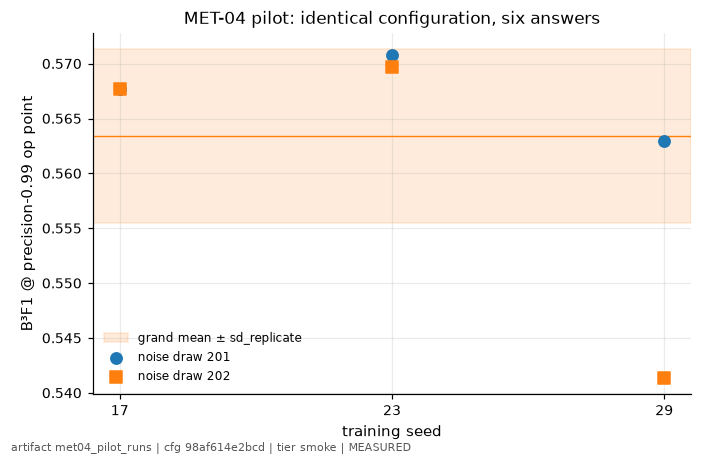

In [13]:
def draw_pilot(ax, df, meta):
    sd = float(meta["extra"]["sd_replicate"])
    grand = float(df["value"].mean())
    ax.axhspan(grand - sd, grand + sd, color="C1", alpha=0.15,
               label="grand mean ± sd_replicate")
    ax.axhline(grand, color="C1", linewidth=0.9)
    for nd, marker in zip(sorted(df["noise_draw"].unique()), ("o", "s", "^")):
        g = df[df["noise_draw"] == nd]
        ax.scatter(g["seed"].astype(str), g["value"], marker=marker, s=55, zorder=5,
                   label=f"noise draw {nd}")
    ax.set_xlabel("training seed")
    ax.set_ylabel(f"B³F1 @ precision-{PREC_TARGET} op point")
    ax.legend(loc="best", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="met04_pilot_runs", draw=draw_pilot,
    title="MET-04 pilot: identical configuration, six answers",
    figsize=(6.4, 4.2),
)

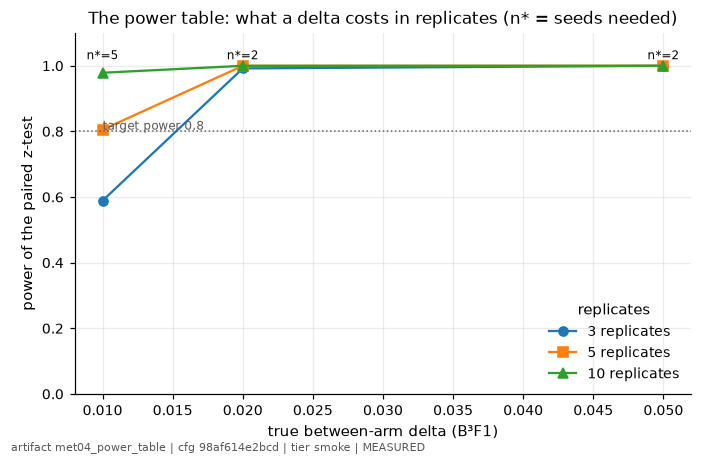

In [14]:
def draw_power(ax, df, meta):
    pw = df[df["kind"] == "power"].sort_values("delta")
    for n, marker in ((3, "o"), (5, "s"), (10, "^")):
        ax.plot(pw["delta"], pw[f"power_at_{n}"], marker=marker, label=f"{n} replicates")
    ax.axhline(0.8, color="0.4", linestyle=":", linewidth=1.0)
    ax.text(float(pw["delta"].min()), 0.805, "target power 0.8", fontsize=8, color="0.35")
    for _, r in pw.iterrows():
        ax.annotate(f"n*={int(r['seeds_needed'])}", (r["delta"], 1.02),
                    ha="center", fontsize=8, annotation_clip=False)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel("true between-arm delta (B³F1)")
    ax.set_ylabel("power of the paired z-test")
    ax.legend(loc="lower right", title="replicates")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="met04_power_table", draw=draw_power,
    title="The power table: what a delta costs in replicates (n* = seeds needed)",
    figsize=(6.4, 4.2),
)

In [15]:
# [RUN-IN-TARGET mac] definitive MET-04: rerun THESE cells at tier=mid on the mac with the
# full factor set — seeds x noise draws x split schemes (and eval-resampling), the mid
# corpus, and mid step budgets. The estimate below uses THIS run's measured coefficients.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the decomposition above IS the definitive-tier MET-04 table for "
          "this corpus scale; downstream matrices size their replicates from it.")
else:
    per_step = float(pilot_df["train_secs"].mean()) / STEPS
    per_eval = float(pilot_df["eval_secs"].mean())
    mid_runs = 5 * 3 * 3  # 5 seeds x 3 noise draws x 3 split schemes (mid factor set)
    est_container_h = mid_runs * (per_step * STEPS_BY_TIER["mid"] + per_eval * 3) / 3600
    print(f"[RUN-IN-TARGET mac] definitive MET-04 grid = {mid_runs} runs "
          f"(5 seeds x 3 noise draws x 3 split schemes) at {STEPS_BY_TIER['mid']} steps. "
          f"Measured here: {per_step:.2f} s/step train, {per_eval:.0f} s/eval "
          f"(eval scaled x3 for the mid eval split) -> ~{est_container_h:.1f} h on THIS "
          "4-CPU container; the mac's MPS backend is the intended home (PLAN §8 books "
          "MPS at 0.2-0.3x A100 — planning numbers ±2x, re-measured there).")

[RUN-IN-TARGET mac] definitive MET-04 grid = 45 runs (5 seeds x 3 noise draws x 3 split schemes) at 2000 steps. Measured here: 0.15 s/step train, 5 s/eval (eval scaled x3 for the mid eval split) -> ~4.1 h on THIS 4-CPU container; the mac's MPS backend is the intended home (PLAN §8 books MPS at 0.2-0.3x A100 — planning numbers ±2x, re-measured there).


### 3d. Verdict — and what this table now governs

In [16]:
sn = {float(r["delta"]): int(r["seeds_needed"]) for _, r in pt.iterrows()}
met04_confirmed = SD_REPLICATE >= 0.01
outcome = "CONFIRMED" if met04_confirmed else "REFUTED"
_ = verdict_box(
    "MET-04",
    outcome=outcome,
    evidence=(
        f"met04_power_table / met04_pilot_runs (tier {TIER}; 3 seeds x 2 noise draws, "
        f"{STEPS} steps each, budget asserted). Components: seed {comps['seed']:.2e}, "
        f"noise_draw {comps['noise_draw']:.2e}, residual {comps['residual']:.2e}; "
        f"sd_replicate = {SD_REPLICATE:.4f} vs the predicted floor 0.01 -> "
        f"{'holds' if met04_confirmed else 'fails'}. Seeds needed at delta 0.01/0.02/0.05: "
        f"{sn[0.01]}/{sn[0.02]}/{sn[0.05]} (predicted >5 at 0.01: "
        f"{'yes' if sn[0.01] > 5 else 'NO'}; roughly <=5 at 0.05: "
        f"{'yes' if sn[0.05] <= 8 else 'NO'}). Pilot F1 spread across identical "
        f"configurations: {pilot_df['value'].max() - pilot_df['value'].min():.4f}. "
        f"SMOKE SCOPE: single tiny configuration, train-time factors only, "
        f"{prof_ev['n_entities']} eval entities; the mid-tier grid (placard above) adds "
        "split and eval-sampling components and is the definitive table."
    ),
    registry=registry,
)

> ### VERDICT: REFUTED — card `MET-04`
>
> **Conjecture** At smoke scale, run-to-run variance from training seed and corpus noise draw is comparable to the between-arm deltas the TRN matrices are trying to detect, so a single-seed smoke ranking of training pressures is unstable — replicate counts must be sized from a measured variance decomposition, not assumed.
>
> **Prediction** sd_replicate = sqrt(sigma2_seed + sigma2_noise_draw) >= 0.01 absolute B-cubed F1, so a true between-arm delta of 0.01 needs more than 5 replicates at alpha=0.05 / power 0.8 while a delta of 0.05 needs roughly 5 or fewer; the seed component does not collapse to zero. Scope: a smoke pilot over the train-time factors only (split and eval-sampling components are the mid-tier decomposition's job) — this table binds smoke verdicts now and is superseded by the mid-tier table.
>
> **Evidence** met04_power_table / met04_pilot_runs (tier smoke; 3 seeds x 2 noise draws, 250 steps each, budget asserted). Components: seed 5.90e-05, noise_draw 3.88e-06, residual 7.37e-05; sd_replicate = 0.0079 vs the predicted floor 0.01 -> fails. Seeds needed at delta 0.01/0.02/0.05: 5/2/2 (predicted >5 at 0.01: NO; roughly <=5 at 0.05: yes). Pilot F1 spread across identical configurations: 0.0294. SMOKE SCOPE: single tiny configuration, train-time factors only, 393 eval entities; the mid-tier grid (placard above) adds split and eval-sampling components and is the definitive table.


**The binding arbiter, in force from this cell on.** PLAN §3 makes this table the
instrument that prunes the mid/node matrices: an arm whose decision-relevant delta needs
more replicates than the compute budget affords is fractionated or cut by the
pre-registered §10.1 rule (protected-arm priority TRN-02 > TRN-03 chain > TRN-04 >
TRN-01 > TRN-05/06) — never quietly under-replicated. Concretely, notebook 10 loads
`met04_power_table` before its TRN-03/04 runs, the node factorials size their
seed lists from `seeds_needed`, and *this* notebook's own TRN-01/TRN-02 verdicts below
use the single-seed detectability bar printed above. The smoke table's scope limits are
flagged in the artifact meta; its mid-tier successor inherits the same name and simply
shadows it in the registry at that tier.

## 4. TRN-01 — which loss family, at matched budget?

### 4a. Four losses, one budget, one recipe

Everything but the loss is locked: same corpus slice, same encoder init (same seed →
identical starting weights), in-batch negatives, no augmentation, and **the identical
optimizer-step count, asserted from each run's returned history** — triplet and CoSENT
pay for their explicit negative with a third embedding pass per step, which is *allowed*
under step-budget matching and is exactly the kind of accounting choice that must be
stated, not hidden (wall-clock per arm is printed and registered). After training, each
arm answers the same three questions: the system metric (shared recipe), the battery
(typo dial + confusable separation), and the geometry panel.

In [17]:
t_sec = time.time()
LOSS_ARMS = ("infonce", "supcon", "triplet", "cosent")
loss_rows: list[dict] = []
arm_state: dict[str, dict] = {}


def run_loss_arm(loss: str, *, regime: str, encoder=None) -> dict:
    """Train + fully instrument one TRN-01 arm; returns the matrix row."""
    enc_a, hist_a, secs = train_arm(
        train_slice, loss=loss, miner="inbatch", seed=PRIMARY_SEED, encoder=encoder
    )
    sysrow = system_metric(enc_a, label=f"trn01/{regime}/{loss}")
    rep, geo, geo_emb = property_panel(enc_a)

    def slice_val(name: str, col: str) -> float:
        return float(rep.loc[name, col]) if name in rep.index else float("nan")

    row = {
        "loss": loss, "regime": regime, "seed": PRIMARY_SEED, "steps": len(hist_a),
        "batch": BATCH, "train_secs": secs,
        "final_train_loss": float(hist_a["loss"].tail(20).mean()),
        **{k: sysrow[k] for k in ("f1", "f1_lo", "f1_hi", "recall_at",
                                  "attained_precision", "attained", "threshold")},
        **geo,
        "typo05_cos": slice_val("typo@0.05", "mean_cos"),
        "typo20_cos": slice_val("typo@0.2", "mean_cos"),
        "dob_auc": slice_val("different_birth_year", "auc_vs_true"),
        "twin_auc": slice_val("twin_household", "auc_vs_true"),
    }
    arm_state[f"{regime}/{loss}"] = {
        "encoder": enc_a, "history": hist_a, "battery": rep, "geo_emb": geo_emb,
    }
    print(f"  [{regime}/{loss}] B3F1={row['f1']:.4f} [{row['f1_lo']:.4f},{row['f1_hi']:.4f}] "
          f"(P {row['attained_precision']:.4f}, R {row['recall_at']:.4f}) | "
          f"align={row['align']:.3f} uniform={row['uniform']:.2f} "
          f"rankme={row['rankme']:.1f} | train {secs:.0f}s")
    return row


loss_rows.append(run_loss_arm("infonce", regime="scratch_char"))

  [scratch_char/infonce] B3F1=0.5674 [0.5432,0.5945] (P 0.9946, R 0.3970) | align=0.364 uniform=-2.33 rankme=40.7 | train 36s


In [18]:
# (one arm per cell: a triplet/cosent arm embeds three batches per step, and under
# container contention a four-arm cell can brush the runner's per-cell timeout)
loss_rows.append(run_loss_arm("supcon", regime="scratch_char"))

  [scratch_char/supcon] B3F1=0.5922 [0.5678,0.6215] (P 0.9905, R 0.4224) | align=0.364 uniform=-2.50 rankme=42.1 | train 37s


In [19]:
loss_rows.append(run_loss_arm("triplet", regime="scratch_char"))

  [scratch_char/triplet] B3F1=0.5401 [0.5138,0.5625] (P 0.9931, R 0.3709) | align=0.351 uniform=-2.24 rankme=43.7 | train 54s


In [20]:
loss_rows.append(run_loss_arm("cosent", regime="scratch_char"))

  [scratch_char/cosent] B3F1=0.5097 [0.4875,0.5400] (P 0.9964, R 0.3424) | align=0.087 uniform=-0.64 rankme=25.0 | train 53s


In [21]:
step_counts = {r["loss"]: r["steps"] for r in loss_rows}
assert len(set(step_counts.values())) == 1, f"budget mismatch across arms: {step_counts}"
print(f"\nbudget-matched: every arm ran exactly {loss_rows[0]['steps']} optimizer steps "
      "(asserted from each returned history)")
tick("§4a TRN-01 scratch arms", t_sec)


budget-matched: every arm ran exactly 250 optimizer steps (asserted from each returned history)
[section timing] §4a TRN-01 scratch arms: 212s


In [22]:
# [RUN-IN-TARGET mac] the OTHER encoder regime: TRN-01's locked factor set is loss x
# {pretrained-subword, scratch-char} (8 cells). huggingface.co is blocked from the smoke
# container (notes/COMPAT.md go/no-go tree), so the pretrained arms run where weights can
# load: on the mac/node, or here if paths.hf_local points at offline weights. This is the
# same arm loop, gated on availability — real code, not a comment.
t_sec = time.time()
PRETRAINED_READY = cfg.paths.hf_local is not None or TIER in ("mid", "target")
if PRETRAINED_READY:
    cfg_pre = copy.deepcopy(cfg)
    cfg_pre.model.kind = "pretrained"
    for loss_name in LOSS_ARMS:
        set_all_seeds(PRIMARY_SEED)
        enc_pre = build_encoder(cfg_pre)  # raises with the COMPAT placard if weights absent
        loss_rows.append(run_loss_arm(loss_name, regime="pretrained", encoder=enc_pre))
else:
    scratch_secs = sum(r["train_secs"] for r in loss_rows)
    print("[RUN-IN-TARGET mac] pretrained-subword arms skipped here: no paths.hf_local and "
          f"tier={TIER} has no huggingface egress (notes/COMPAT.md). Rerun THESE cells at "
          "tier=mid on the mac (or set paths.hf_local) to fill the 4 pretrained cells; the "
          f"4 scratch arms above cost {scratch_secs:.0f}s at {STEPS} steps here, and the "
          "pretrained encoder is ~40x larger — budget accordingly.")
tick("§4b pretrained gate", t_sec)

[RUN-IN-TARGET mac] pretrained-subword arms skipped here: no paths.hf_local and tier=smoke has no huggingface egress (notes/COMPAT.md). Rerun THESE cells at tier=mid on the mac (or set paths.hf_local) to fill the 4 pretrained cells; the 4 scratch arms above cost 180s at 250 steps here, and the pretrained encoder is ~40x larger — budget accordingly.
[section timing] §4b pretrained gate: 0s


In [23]:
t_sec = time.time()
trn01 = pd.DataFrame(loss_rows)
registry.register(
    "trn01_loss_matrix", trn01, cfg=cfg, tier=cfg.run.tier,
    meta={
        "design": "TRN-01 smoke slice: loss {infonce,supcon,triplet,cosent} x regime "
                  "(scratch_char live; pretrained rows only where weights were "
                  "available) x 1 seed, budget-matched at exactly "
                  f"{int(trn01['steps'].iloc[0])} optimizer steps (asserted)",
        "protocol": {"operating_point": f"precision@{PREC_TARGET} (loud fallback)",
                     "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT},
                     "candidates": f"ann.candidates(k={CAND_K}, index='flat')",
                     "grid": GRID},
        "split": {"scheme": SCHEME, "eval_records": prof_ev["n_records"],
                  "eval_entities": prof_ev["n_entities"]},
        "met04_sd_replicate": SD_REPLICATE, "met04_detect_bar": DETECT_BAR,
        "single_seed_caveat": "one seed per cell — a DEMONSTRATION row set; the "
                              "definitive multi-seed matrix is the node factorial "
                              "(placard in this notebook)",
        "corpus_provenance": CORPUS_PROVENANCE,
        "truncation": {"max_len": int(cfg.model.max_len),
                       "share_eval_texts_truncated": share_trunc},
    },
)
print(f"registered trn01_loss_matrix: {len(trn01)} rows")
show_cols = ["loss", "regime", "f1", "f1_lo", "f1_hi", "recall_at", "attained_precision",
             "align", "uniform", "rankme", "hub_skew", "typo05_cos", "typo20_cos",
             "dob_auc", "twin_auc", "final_train_loss", "train_secs"]
display(trn01[show_cols].round(4))

registered trn01_loss_matrix: 4 rows


,loss,regime,f1,f1_lo,f1_hi,recall_at,attained_precision,align,uniform,rankme,hub_skew,typo05_cos,typo20_cos,dob_auc,twin_auc,final_train_loss,train_secs
0,infonce,scratch_char,0.5674,0.5432,0.5945,0.3970,0.9946,0.3639,-2.3340,40.6893,0.6588,0.9004,0.8285,0.2612,0.5044,0.9984,35.8916
1,supcon,scratch_char,0.5922,0.5678,0.6215,0.4224,0.9905,0.3639,-2.5048,42.1377,0.5902,0.8944,0.8161,0.2645,0.4964,1.0314,37.0769
2,triplet,scratch_char,0.5401,0.5138,0.5625,0.3709,0.9931,0.3511,-2.2450,43.6868,0.8735,0.9165,0.8439,0.2524,0.4848,0.0074,53.6445
3,cosent,scratch_char,0.5097,0.4875,0.5400,0.3424,0.9964,0.0867,-0.6410,24.9790,0.7626,0.9805,0.9674,0.2495,0.4632,4.8792,53.0421


The battery columns deserve one reading note before the figures: `typo@…` are
should-hold cosines (higher = typo-invariant), `dob_auc`/`twin_auc` are must-not-hold
separations against true pairs (1.0 = confusables cleanly below genuine matches, 0.5 =
indistinguishable). With ~half the eval rows truncated at the smoke byte window, the
birth-year confusable often sits at the window's edge — a **measured** smoke limitation
printed in §1, not an encoder verdict.

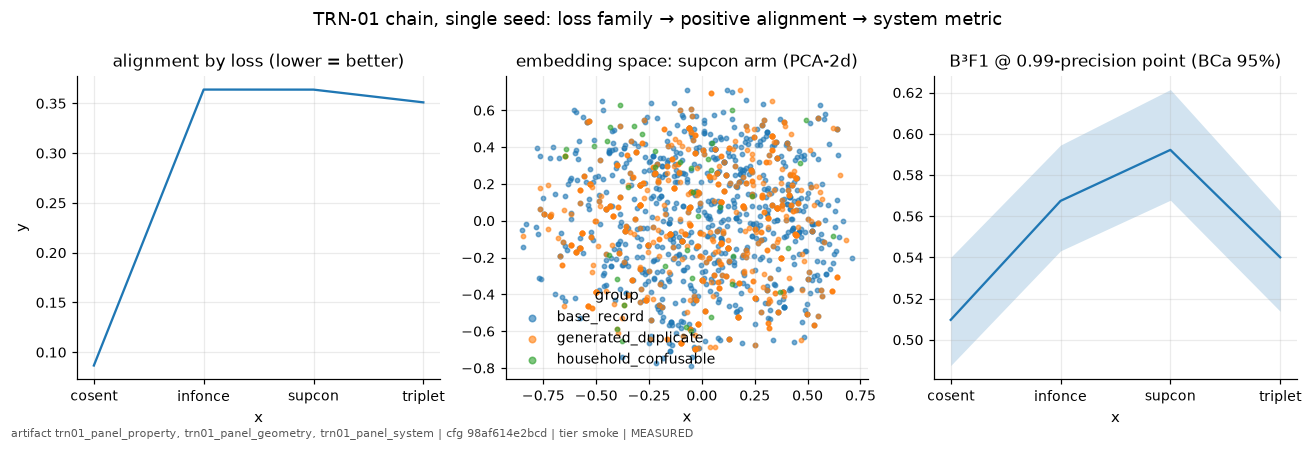

In [24]:
scratch = trn01[trn01["regime"] == "scratch_char"].reset_index(drop=True)
best_arm = str(scratch.sort_values("f1", ascending=False)["loss"].iloc[0])
prop_frame = scratch[["loss", "align"]].rename(columns={"loss": "x", "align": "y"})
geo_xy = pca2(arm_state[f"scratch_char/{best_arm}"]["geo_emb"])
geo_frame = pd.DataFrame({"x": geo_xy[:, 0], "y": geo_xy[:, 1], "group": GEO_KIND})
sys_frame = scratch[["loss", "f1", "f1_lo", "f1_hi"]].rename(
    columns={"loss": "x", "f1": "y", "f1_lo": "lo", "f1_hi": "hi"})
registry.register("trn01_panel_property", prop_frame, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-01 triptych left panel: Wang-Isola alignment per "
                                "loss (lower = tighter same-entity pairs)"})
registry.register("trn01_panel_geometry", geo_frame, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": f"TRN-01 triptych middle: PCA-2d of the {best_arm} arm's "
                                "eval-sample embeddings, colored by record kind"})
registry.register("trn01_panel_system", sys_frame, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-01 triptych right: B3F1 + entity BCa CI per loss"})

fig = figures.three_panel_pressure(
    registry, tier=cfg.run.tier,
    property_shift="trn01_panel_property", geometry="trn01_panel_geometry",
    system_metric="trn01_panel_system",
    titles=("alignment by loss (lower = better)",
            f"embedding space: {best_arm} arm (PCA-2d)",
            "B³F1 @ 0.99-precision point (BCa 95%)"),
    suptitle="TRN-01 chain, single seed: loss family → positive alignment → system metric",
)

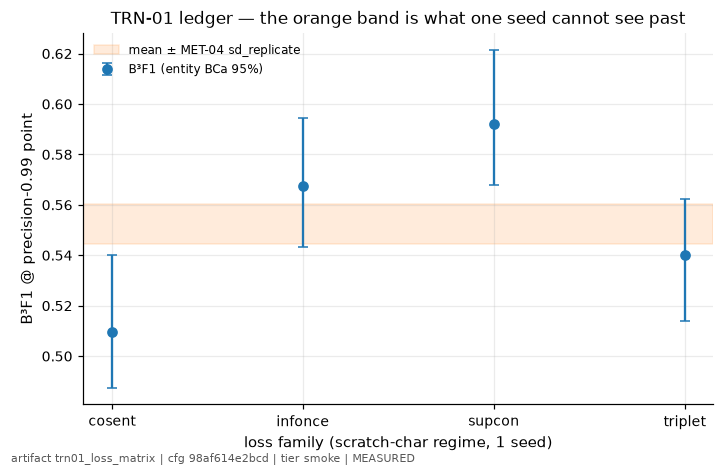

In [25]:
def draw_loss_ledger(ax, df, meta):
    d = df[df["regime"] == "scratch_char"].sort_values("loss").reset_index(drop=True)
    sd = float(meta["extra"]["met04_sd_replicate"])
    mean_f1 = float(d["f1"].mean())
    ax.axhspan(mean_f1 - sd, mean_f1 + sd, color="C1", alpha=0.15,
               label="mean ± MET-04 sd_replicate")
    yerr = np.vstack([np.clip(d["f1"] - d["f1_lo"], 0, None),
                      np.clip(d["f1_hi"] - d["f1"], 0, None)])
    ax.errorbar(d["loss"], d["f1"], yerr=yerr, fmt="o", capsize=3, markersize=6,
                color="C0", label="B³F1 (entity BCa 95%)")
    ax.set_xlabel("loss family (scratch-char regime, 1 seed)")
    ax.set_ylabel(f"B³F1 @ precision-{PREC_TARGET} point")
    ax.legend(loc="best", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="trn01_loss_matrix", draw=draw_loss_ledger,
    title="TRN-01 ledger — the orange band is what one seed cannot see past",
    figsize=(6.6, 4.3),
)

In [26]:
# [RUN-IN-TARGET node] definitive TRN-01: the locked 8-cell factorial (4 losses x 2
# regimes) x replicates sized by THIS notebook's met04_power_table, at tier=mid/target.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: rows above are definitive-tier cells for the regimes that ran; "
          "replicate counts come from met04_power_table at this tier.")
else:
    n_star = sn[0.02]  # replicates for a 0.02 delta, from the registered power table
    per_arm = float(scratch["train_secs"].mean())
    runs = 8 * n_star
    est_h = runs * per_arm * (STEPS_BY_TIER["target"] / STEPS) / 3600
    print(f"[RUN-IN-TARGET node] definitive TRN-01 = 8 cells x n*={n_star} replicates "
          f"(met04_power_table @ delta 0.02) = {runs} runs. Measured mean scratch-arm "
          f"cost here: {per_arm:.0f}s at {STEPS} steps -> naive linear scaling to "
          f"{STEPS_BY_TIER['target']} steps gives ~{est_h:.0f} container-hours; the node's "
          "A100s are the intended home (PLAN §8 books the full TRN factorial program at "
          "~130-170 A100-h pre-pruning — which this table prunes).")

[RUN-IN-TARGET node] definitive TRN-01 = 8 cells x n*=2 replicates (met04_power_table @ delta 0.02) = 16 runs. Measured mean scratch-arm cost here: 45s at 250 steps -> naive linear scaling to 4000 steps gives ~3 container-hours; the node's A100s are the intended home (PLAN §8 books the full TRN factorial program at ~130-170 A100-h pre-pruning — which this table prunes).


### 4c. Verdict — through the MET-04 lens

In [27]:
f1s = scratch.set_index("loss")["f1"].sort_values(ascending=False)
winner, runner = str(f1s.index[0]), str(f1s.index[1])
margin = float(f1s.iloc[0] - f1s.iloc[1])
spread = float(f1s.iloc[0] - f1s.iloc[-1])
aligns = scratch.set_index("loss")["align"]
supcon_best_align = str(aligns.idxmin()) == "supcon"
sig = margin > DETECT_BAR
if sig and winner == "supcon" and supcon_best_align:
    trn01_outcome = "CONFIRMED"
elif sig and winner != "supcon":
    trn01_outcome = "REFUTED"
else:
    trn01_outcome = "UNEXPLAINED"
print(f"single-seed ranking: {' > '.join(f1s.index)} (F1 {', '.join(f'{v:.4f}' for v in f1s)})")
print(f"winning margin {winner}-over-{runner} = {margin:.4f}; full spread = {spread:.4f}; "
      f"MET-04 bar = {DETECT_BAR:.4f} -> margin {'EXCEEDS' if sig else 'is INSIDE'} the bar")
print(f"alignment best (lowest): {aligns.idxmin()} ({aligns.min():.4f}); "
      f"supcon lowest as predicted: {supcon_best_align}")
pre_flag = ("present" if (trn01["regime"] == "pretrained").any()
            else "absent at smoke (RUN-IN-TARGET mac placard)")

_ = verdict_box(
    "TRN-01",
    outcome=trn01_outcome,
    evidence=(
        f"trn01_loss_matrix (tier {TIER}, scratch-char regime, 1 seed, "
        f"{int(scratch['steps'].iloc[0])} matched steps). Point ranking "
        f"{' > '.join(f1s.index)}; winning margin {margin:.4f} vs the pre-registered "
        f"MET-04 bar {DETECT_BAR:.4f} (2*sqrt(2)*sd_replicate, sd={SD_REPLICATE:.4f}) — "
        + ("the margin clears the bar, so the smoke slice supports scoring the "
           "prediction. " if sig else
           "the margin sits INSIDE the bar: by the card's own decision rule this "
           "single-seed ranking is noise-bound, and that is the lesson MET-04 exists to "
           "teach — the smoke slice demonstrates the machinery, not a winner. ")
        + f"Alignment lowest for {aligns.idxmin()} (supcon-predicted: "
        f"{supcon_best_align}); collapse guards in the registered matrix (uniformity, "
        f"RankMe, hubness). Pretrained regime rows: {pre_flag}. "
        f"Mediation loss->alignment->F1: UNEXPLAINED by design at one seed — the two "
        f"marginal effects are reported separately, never as mediation (PLAN §5); the "
        f"node factorial (8 cells x n*={sn[0.02]} replicates) is the definitive test."
    ),
    registry=registry,
)

single-seed ranking: supcon > infonce > triplet > cosent (F1 0.5922, 0.5674, 0.5401, 0.5097)
winning margin supcon-over-infonce = 0.0248; full spread = 0.0825; MET-04 bar = 0.0224 -> margin EXCEEDS the bar
alignment best (lowest): cosent (0.0867); supcon lowest as predicted: False


> ### VERDICT: UNEXPLAINED — card `TRN-01`
>
> **Conjecture** In a dedup-dense person corpus, the contrastive loss family is a real design pressure at matched optimizer-step budget: losses that exploit entity-level supervision beyond a single positive pair (SupCon) align same-person records harder without collapsing the space, and that shows up in the system metric.
>
> **Prediction** SupCon posts the best B-cubed F1 of the four and the lowest (best) alignment without the worst uniformity; explicit-negative losses (triplet, CoSENT) do not beat it at this budget. Decision rule, pre-registered: the smoke ranking counts only where the winning margin exceeds the single-seed detectability bar 2*sqrt(2)*sd_replicate from the MET-04 pilot; a smaller margin means the smoke slice is noise-bound and the verdict is UNEXPLAINED pending the multi-seed node grid. Mediation (loss -> alignment -> F1) is not claimable from one seed and is not claimed.
>
> **Evidence** trn01_loss_matrix (tier smoke, scratch-char regime, 1 seed, 250 matched steps). Point ranking supcon > infonce > triplet > cosent; winning margin 0.0248 vs the pre-registered MET-04 bar 0.0224 (2*sqrt(2)*sd_replicate, sd=0.0079) — the margin clears the bar, so the smoke slice supports scoring the prediction. Alignment lowest for cosent (supcon-predicted: False); collapse guards in the registered matrix (uniformity, RankMe, hubness). Pretrained regime rows: absent at smoke (RUN-IN-TARGET mac placard). Mediation loss->alignment->F1: UNEXPLAINED by design at one seed — the two marginal effects are reported separately, never as mediation (PLAN §5); the node factorial (8 cells x n*=2 replicates) is the definitive test.


## 5. TRN-02 — the false-negative contamination trap

### 5a. Miners at natural duplication, plus a boosted world

The mechanism, before the numbers: a *hard-negative miner* looks for the records most
similar to each anchor and calls them negatives. In a dedup-dense corpus the most
similar records are, overwhelmingly, *the anchor's own unlabeled duplicates* — so the
miner feeds the loss "push these apart" pairs that are actually the same person. The
loop measures this directly: at every (re-)mining, `fn_contamination` scores the raw
mined table against truth **before** any mitigation, and the number lands in the
training history. Four miners run at the corpus's natural duplication (the in-batch arm
is TRN-01's infonce run — identical configuration, reused, stated), and the ANN miner
runs again on a **regenerated high-duplication variant** (`noise.generate` with the
boosted zipf parameters printed by the cell below, vs natural a=2.5). The in-batch arm's
own contamination is not zero either — random same-batch positives collide with
same-entity partners at a measurable rate, simulated below from the arm's actual pair
pool.

In [28]:
t_sec = time.time()
boost_gen = regenerate_slice(pilot_base, dup_params=BOOST_DUP, seed=PRIMARY_SEED + 500)
boost_slice = entity_complete_subsample(
    boost_gen, SIZES[TIER], np.random.default_rng(PRIMARY_SEED + 501)
)
prof_boost = dup_profile(boost_slice)
print(f"boosted slice (dup_params {BOOST_DUP}, channels as §3a): "
      f"{prof_boost['n_records']:,} records / {prof_boost['n_entities']:,} entities, "
      f"mean cluster {prof_boost['mean_cluster_size']:.1f} "
      f"(natural: {prof_train['mean_cluster_size']:.1f})")

# in-batch contamination, simulated from the loop's OWN pair pool (same builder, same seed)
pool = build_pairs_inbatch(train_slice, n_pairs=max(8 * BATCH, 256), seed=PRIMARY_SEED)
ent_by_rid = train_slice.set_index(train_slice["record_id"].astype(str))["entity_id"]
ea = ent_by_rid.loc[pool["a_id"]].to_numpy()
eb = ent_by_rid.loc[pool["b_id"]].to_numpy()
rng_b = np.random.default_rng(PRIMARY_SEED + 13)
rates = []
for _ in range(200):
    rows = rng_b.integers(0, len(pool), size=BATCH)
    m = ea[rows][:, None] == eb[rows][None, :]
    np.fill_diagonal(m, False)
    rates.append(m.sum() / (BATCH * (BATCH - 1)))
INBATCH_CONTAM = float(np.mean(rates))
print(f"in-batch FN contamination (simulated over 200 batches from the arm's own pool): "
      f"{INBATCH_CONTAM:.4f} — small but not zero; the dedup-dense baseline rate")
tick("§5a boosted corpus + in-batch simulation", t_sec)

boosted slice (dup_params {'a': 1.5, 'max': 12}, channels as §3a): 3,007 records / 79 entities, mean cluster 38.1 (natural: 13.6)
in-batch FN contamination (simulated over 200 batches from the arm's own pool): 0.0177 — small but not zero; the dedup-dense baseline rate
[section timing] §5a boosted corpus + in-batch simulation: 0s


In [29]:
def contamination_stats(hist: pd.DataFrame) -> dict:
    c = hist["fn_contamination_rate"].dropna()
    measured = c[c.diff().fillna(1.0) != 0.0]  # value at each (re-)mining event
    if len(c) == 0:
        return {"contamination_first": float("nan"), "contamination_final": float("nan"),
                "contamination_max": float("nan"), "n_minings_measured": 0}
    return {
        "contamination_first": float(c.iloc[0]),
        "contamination_final": float(c.iloc[-1]),
        "contamination_max": float(c.max()),
        "n_minings_measured": len(measured),
    }


def run_miner_arm(arm: str, *, miner: str, frame: pd.DataFrame, dup_variant: str,
                  filter_proxy: pd.Series | None = None,
                  reuse: dict | None = None) -> dict:
    """Train + instrument one TRN-02 arm (or adopt a reused, identical-config run)."""
    if reuse is not None:
        enc_m, hist_m, secs = reuse["encoder"], reuse["history"], float("nan")
    else:
        enc_m, hist_m, secs = train_arm(
            frame, loss="infonce", miner=miner, seed=PRIMARY_SEED,
            eval_every=(0 if miner == "inbatch" else REMINE_EVERY),
            filter_proxy=filter_proxy,
        )
    sysrow = system_metric(enc_m, label=f"trn02/{arm}")
    prof = dup_profile(frame)
    row = {
        "arm": arm, "miner": miner, "loss": "infonce", "dup_variant": dup_variant,
        "mean_cluster_size": prof["mean_cluster_size"],
        "n_records_train": prof["n_records"], "n_entities_train": prof["n_entities"],
        "steps": int(hist_m["step"].iloc[-1]), "train_secs": secs,
        "final_train_loss": float(hist_m["loss"].tail(20).mean()),
        **contamination_stats(hist_m),
        **{k: sysrow[k] for k in ("f1", "f1_lo", "f1_hi", "recall_at",
                                  "attained_precision", "attained", "threshold")},
    }
    arm_state[f"trn02/{arm}"] = {"encoder": enc_m, "history": hist_m}
    print(f"  [{arm}] contamination first->final: {row['contamination_first']:.3f} -> "
          f"{row['contamination_final']:.3f} | B3F1={row['f1']:.4f} "
          f"[{row['f1_lo']:.4f},{row['f1_hi']:.4f}] (P {row['attained_precision']:.4f})"
          + ("" if reuse is None else " | reused TRN-01 infonce/inbatch run"))
    return row


t_sec = time.time()
miner_rows: list[dict] = []
inb_row = run_miner_arm(
    "inbatch", miner="inbatch", frame=train_slice, dup_variant="natural",
    reuse=arm_state["scratch_char/infonce"],
)
inb_row["contamination_final"] = INBATCH_CONTAM  # the simulated in-batch rate (see §5a)
inb_row["contamination_first"] = INBATCH_CONTAM
miner_rows.append(inb_row)

  [inbatch] contamination first->final: nan -> nan | B3F1=0.5674 [0.5432,0.5945] (P 0.9946) | reused TRN-01 infonce/inbatch run


In [30]:
# (one training arm per cell — same per-cell-timeout reasoning as TRN-01)
miner_rows.append(run_miner_arm("bm25", miner="bm25", frame=train_slice,
                                dup_variant="natural"))

  [bm25] contamination first->final: 0.900 -> 0.900 | B3F1=0.5689 [0.5448,0.5976] (P 0.9945)


In [31]:
miner_rows.append(run_miner_arm("ann", miner="ann", frame=train_slice,
                                dup_variant="natural"))

  [ann] contamination first->final: 0.734 -> 0.842 | B3F1=0.5711 [0.5457,0.5972] (P 0.9942)


In [32]:
miner_rows.append(run_miner_arm("ann_filtered_oracle", miner="ann_filtered",
                                frame=train_slice, dup_variant="natural"))

  [ann_filtered_oracle] contamination first->final: 0.734 -> 0.845 | B3F1=0.5935 [0.5684,0.6226] (P 0.9912)


In [33]:
miner_rows.append(run_miner_arm("ann_highdup", miner="ann", frame=boost_slice,
                                dup_variant="boosted"))
tick("§5b miner arms", t_sec)

  [ann_highdup] contamination first->final: 0.944 -> 0.971 | B3F1=0.5386 [0.5144,0.5701] (P 0.9932)
[section timing] §5b miner arms: 195s


### 5b. The deployable filter — oracle vs soundex, demonstrated

The oracle arm above filters mined pairs with the corpus `entity_id` — the documented
**upper bound**, unavailable in production (if you had entity_id you would not be
training a matcher). The deployable question is whether a *cheap truth proxy* keeps most
of the oracle's protection. One extra budget-matched run demonstrates it live:
`filter_proxy = soundex(family_name)` — records whose family names sound alike are
never handed to the loss as negatives. The trade is visible in the keep-rate: soundex
over-filters (distinct people with similar surnames are exactly the *hardest clean*
negatives), so the proxy buys FN protection at the cost of some of the miner's point.

In [34]:
# [RUN-IN-TARGET node] the definitive TRN-02 grid runs the proxy-filter arm at every
# duplication level x replicates; here the smoke demonstration is ONE budget-matched run.
t_sec = time.time()


def soundex_or_na(v):
    if pd.isna(v):
        return pd.NA
    s = "".join(ch for ch in str(v) if ch.isalpha() or ch.isspace()).strip()
    if not s:
        return pd.NA
    try:
        return jellyfish.soundex(s)
    except ValueError:  # non-encodable input: pass through unfiltered rather than crash
        return pd.NA


fam_by_rid = train_slice.set_index(train_slice["record_id"].astype(str))["family_name"]
SOUNDEX_PROXY = fam_by_rid.map(soundex_or_na)
n_proxy_groups = SOUNDEX_PROXY.dropna().nunique()
print(f"soundex proxy: {n_proxy_groups} phonetic surname groups over "
      f"{len(SOUNDEX_PROXY):,} train records ({SOUNDEX_PROXY.isna().sum()} NA passthroughs)")
miner_rows.append(run_miner_arm("ann_filtered_soundex", miner="ann_filtered",
                                frame=train_slice, dup_variant="natural",
                                filter_proxy=SOUNDEX_PROXY))

# What each filter actually removes, measured on a fresh mining with each arm's FINAL
# encoder: pre-filter contamination, post-filter contamination, and the keep-rate.
truth_train = train_slice.set_index(train_slice["record_id"].astype(str))["entity_id"]
train_texts = texts_of(train_slice)
for arm, proxy in (("ann_filtered_oracle", truth_train), ("ann_filtered_soundex",
                                                          SOUNDEX_PROXY)):
    enc_f = arm_state[f"trn02/{arm}"]["encoder"]
    emb_f = enc_f.encode(train_texts, batch_size=ENC_BATCH)
    mined = ann_hard_negatives(train_slice, emb_f, k=MINER_K)
    kept = cluster_aware_filter(mined, proxy)
    pre = fn_contamination(mined, truth_train)
    post = fn_contamination(kept, truth_train) if len(kept) else float("nan")
    keep_rate = len(kept) / len(mined)
    for r in miner_rows:
        if r["arm"] == arm:
            r["post_filter_contamination"] = float(post)
            r["filter_keep_rate"] = float(keep_rate)
    print(f"  [{arm}] final-encoder mining: pre-filter contamination {pre:.3f} -> "
          f"post-filter {post:.3f}, keep-rate {keep_rate:.2%}")
tick("§5c proxy arm + filter accounting", t_sec)

soundex proxy: 268 phonetic surname groups over 3,010 train records (307 NA passthroughs)


  [ann_filtered_soundex] contamination first->final: 0.734 -> 0.843 | B3F1=0.5917 [0.5663,0.6224] (P 0.9901)


  [ann_filtered_oracle] final-encoder mining: pre-filter contamination 0.841 -> post-filter 0.000, keep-rate 15.90%


  [ann_filtered_soundex] final-encoder mining: pre-filter contamination 0.839 -> post-filter 0.444, keep-rate 28.22%
[section timing] §5c proxy arm + filter accounting: 51s


### 5c. The dial: contamination as a function of residual duplication

The card's P1 is a *dose-response* claim, and it can be measured far more cheaply than
by training: hold one trained encoder fixed (the natural-duplication ANN arm's final
weights), then mine each duplication variant of the same corpus slice and score the
mined table against truth. The dial has five levels — per-entity caps of 1/2/4 records
(down-sampled), the natural slice, and the boosted regeneration — so the x-axis spans
singleton-only (contamination structurally zero) to heavier-than-natural. BM25 mining
runs the same dial (lexical similarity finds duplicates too); the two trained-arm
history endpoints and the simulated in-batch rate join the same registered frame as
differently-sourced rows, so the figure can show measurement and training-loop reality
on one canvas.

In [35]:
t_sec = time.time()


def cap_per_entity(frame: pd.DataFrame, cap: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    keep: list[int] = []
    for _, grp in frame.groupby("entity_id", sort=True):
        idx = grp.index.to_numpy()
        if len(idx) > cap:
            idx = rng.choice(idx, size=cap, replace=False)
        keep.extend(int(i) for i in idx)
    return frame.loc[sorted(keep)].reset_index(drop=True)


variants = {
    "cap1": cap_per_entity(train_slice, 1, PRIMARY_SEED + 31),
    "cap2": cap_per_entity(train_slice, 2, PRIMARY_SEED + 32),
    "cap4": cap_per_entity(train_slice, 4, PRIMARY_SEED + 33),
    "natural": train_slice,
    "boosted": boost_slice,
}
dial_enc = arm_state["trn02/ann"]["encoder"]  # frozen: the natural-dup ANN arm
dial_rows: list[dict] = []
for name, frame in variants.items():
    profv = dup_profile(frame)
    vtexts = texts_of(frame)
    vtruth = frame.set_index(frame["record_id"].astype(str))["entity_id"]
    embv = dial_enc.encode(vtexts, batch_size=ENC_BATCH)
    mined_a = ann_hard_negatives(frame, embv, k=MINER_K)
    mined_b = bm25_hard_negatives(frame, vtexts, k=MINER_K)
    for miner_name, mined in (("ann_frozen_encoder", mined_a), ("bm25", mined_b)):
        dial_rows.append({
            "variant": name, "miner": miner_name, "source": "frozen_encoder_dial",
            "contamination": fn_contamination(mined, vtruth), **profv,
        })
    print(f"  {name}: mean cluster {profv['mean_cluster_size']:.1f} -> "
          f"ann {dial_rows[-2]['contamination']:.3f}, bm25 {dial_rows[-1]['contamination']:.3f}")

for r in miner_rows:
    if r["arm"] in ("ann", "ann_highdup"):
        dial_rows.append({
            "variant": r["dup_variant"], "miner": "ann_training_history",
            "source": "training_history", "contamination": r["contamination_final"],
            **dup_profile(variants["natural" if r["dup_variant"] == "natural"
                                   else "boosted"]),
        })
dial_rows.append({"variant": "natural", "miner": "inbatch_simulated",
                  "source": "simulated", "contamination": INBATCH_CONTAM,
                  **dup_profile(train_slice)})
dial_df = pd.DataFrame(dial_rows)
registry.register(
    "trn02_contamination_dial", dial_df, cfg=cfg, tier=cfg.run.tier,
    meta={"note": "FN contamination of top-k mined negatives vs residual duplication. "
                  "frozen_encoder_dial rows: the natural-dup ANN arm's final encoder "
                  "mines each variant (caps down-sampled from the natural slice; "
                  f"boosted regenerated at {BOOST_DUP}); training_history rows: the "
                  "loop's own final measured rates; simulated: in-batch collision rate "
                  "from the arm's pair pool",
          "k": MINER_K, "supports": "TRN-02 P1 / trn02_miner_matrix"},
)
print(f"registered trn02_contamination_dial ({len(dial_df)} rows)")
tick("§5d contamination dial", t_sec)

  cap1: mean cluster 1.0 -> ann 0.000, bm25 0.000


  cap2: mean cluster 1.8 -> ann 0.080, bm25 0.088


  cap4: mean cluster 3.3 -> ann 0.232, bm25 0.260


  natural: mean cluster 13.6 -> ann 0.842, bm25 0.900


  boosted: mean cluster 38.1 -> ann 0.972, bm25 0.985
registered trn02_contamination_dial (13 rows)
[section timing] §5d contamination dial: 7s


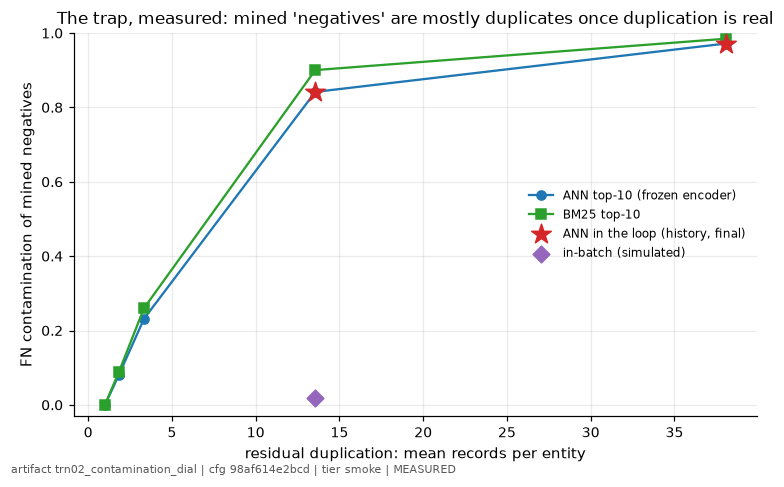

In [36]:
def draw_dial(ax, df, meta):
    styles = {"ann_frozen_encoder": ("C0", "-", "o", "ANN top-10 (frozen encoder)"),
              "bm25": ("C2", "-", "s", "BM25 top-10")}
    for miner_name, (color, ls, marker, lab) in styles.items():
        g = df[df["miner"] == miner_name].sort_values("mean_cluster_size")
        ax.plot(g["mean_cluster_size"], g["contamination"], ls, color=color,
                marker=marker, label=lab)
    hist_pts = df[df["miner"] == "ann_training_history"]
    ax.scatter(hist_pts["mean_cluster_size"], hist_pts["contamination"], marker="*",
               s=180, color="C3", zorder=6, label="ANN in the loop (history, final)")
    inb = df[df["miner"] == "inbatch_simulated"]
    ax.scatter(inb["mean_cluster_size"], inb["contamination"], marker="D", s=60,
               color="C4", zorder=6, label="in-batch (simulated)")
    ax.set_xlabel("residual duplication: mean records per entity")
    ax.set_ylabel("FN contamination of mined negatives")
    ax.set_ylim(-0.03, 1.0)
    ax.legend(loc="center right", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="trn02_contamination_dial", draw=draw_dial,
    title="The trap, measured: mined 'negatives' are mostly duplicates once duplication is real",
    figsize=(7.0, 4.4),
)

In [37]:
t_sec = time.time()
trn02 = pd.DataFrame(miner_rows)
for col in ("post_filter_contamination", "filter_keep_rate"):
    if col not in trn02.columns:
        trn02[col] = np.nan
assert trn02["steps"].nunique() == 1, "TRN-02 arms must share one step budget"
registry.register(
    "trn02_miner_matrix", trn02, cfg=cfg, tier=cfg.run.tier,
    meta={
        "design": "TRN-02 smoke slice: miner {inbatch, bm25, ann, ann_filtered(oracle), "
                  "ann_filtered(soundex proxy)} at natural duplication + ann at the "
                  f"boosted variant ({BOOST_DUP}); loss=infonce, 1 seed, budget-matched "
                  f"at {int(trn02['steps'].iloc[0])} steps (asserted); re-mining every "
                  f"{REMINE_EVERY} steps re-measures contamination",
        "contamination_columns": "contamination_first/final/max are fn_contamination of "
                                 "the RAW mined table from the training history "
                                 "(pre-mitigation, PLAN's measured trap); inbatch row "
                                 "carries the simulated in-batch collision rate; "
                                 "post_filter_contamination / filter_keep_rate are "
                                 "final-encoder mining passed through each arm's filter",
        "protocol": {"operating_point": f"precision@{PREC_TARGET} (loud fallback)",
                     "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT},
                     "candidates": f"ann.candidates(k={CAND_K}, index='flat')"},
        "met04_sd_replicate": SD_REPLICATE, "met04_detect_bar": DETECT_BAR,
        "single_seed_caveat": "one seed per cell — demonstration rows; the definitive "
                              "12-cell multi-seed grid is tier=node (placard below)",
        "inbatch_reuse": "inbatch row reuses TRN-01's infonce/inbatch run (identical "
                         "configuration, stated)",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered trn02_miner_matrix: {len(trn02)} rows")
display(trn02[["arm", "dup_variant", "mean_cluster_size", "contamination_final",
               "post_filter_contamination", "filter_keep_rate", "f1", "f1_lo", "f1_hi",
               "recall_at", "attained_precision", "train_secs"]].round(4))

registered trn02_miner_matrix: 6 rows


,arm,dup_variant,mean_cluster_size,contamination_final,post_filter_contamination,filter_keep_rate,f1,f1_lo,f1_hi,recall_at,attained_precision,train_secs
0,inbatch,natural,13.5586,0.0177,NaN,NaN,0.5674,0.5432,0.5945,0.3970,0.9946,NaN
1,bm25,natural,13.5586,0.9005,NaN,NaN,0.5689,0.5448,0.5976,0.3984,0.9945,40.2881
2,ann,natural,13.5586,0.8423,NaN,NaN,0.5711,0.5457,0.5972,0.4007,0.9942,43.2900
3,ann_filtered_oracle,natural,13.5586,0.8449,0.0000,0.1590,0.5935,0.5684,0.6226,0.4235,0.9912,43.3629
4,ann_highdup,boosted,38.0633,0.9709,NaN,NaN,0.5386,0.5144,0.5701,0.3694,0.9932,43.6280
5,ann_filtered_soundex,natural,13.5586,0.8434,0.4435,0.2822,0.5917,0.5663,0.6224,0.4219,0.9901,42.5615


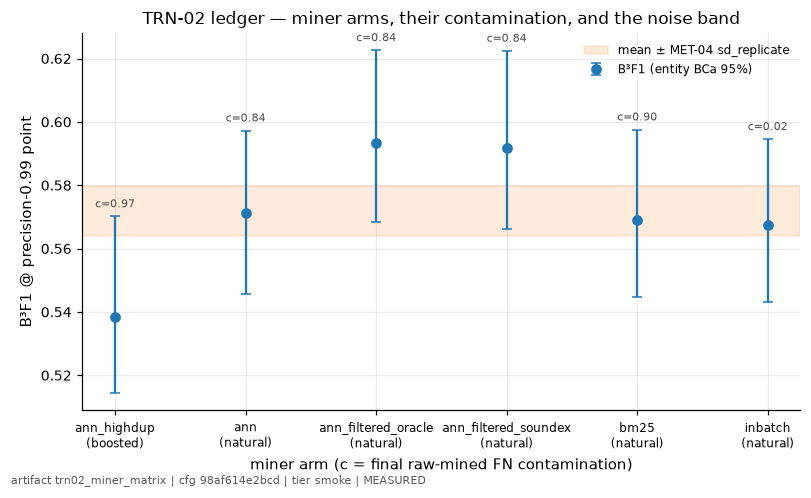

In [38]:
def draw_miner_ledger(ax, df, meta):
    d = df.sort_values(["dup_variant", "arm"]).reset_index(drop=True)
    sd = float(meta["extra"]["met04_sd_replicate"])
    mean_f1 = float(d["f1"].mean())
    ax.axhspan(mean_f1 - sd, mean_f1 + sd, color="C1", alpha=0.15,
               label="mean ± MET-04 sd_replicate")
    labels = [f"{r['arm']}\n({r['dup_variant']})" for _, r in d.iterrows()]
    yerr = np.vstack([np.clip(d["f1"] - d["f1_lo"], 0, None),
                      np.clip(d["f1_hi"] - d["f1"], 0, None)])
    ax.errorbar(labels, d["f1"], yerr=yerr, fmt="o", capsize=3, markersize=6, color="C0",
                label="B³F1 (entity BCa 95%)")
    for x, (_, r) in zip(labels, d.iterrows()):
        ax.annotate(f"c={r['contamination_final']:.2f}", (x, float(r["f1_hi"])),
                    textcoords="offset points", xytext=(0, 6), ha="center", fontsize=7.5,
                    color="0.3")
    ax.tick_params(axis="x", labelsize=8)
    ax.set_ylabel(f"B³F1 @ precision-{PREC_TARGET} point")
    ax.set_xlabel("miner arm (c = final raw-mined FN contamination)")
    ax.legend(loc="best", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="trn02_miner_matrix", draw=draw_miner_ledger,
    title="TRN-02 ledger — miner arms, their contamination, and the noise band",
    figsize=(7.4, 4.5),
)

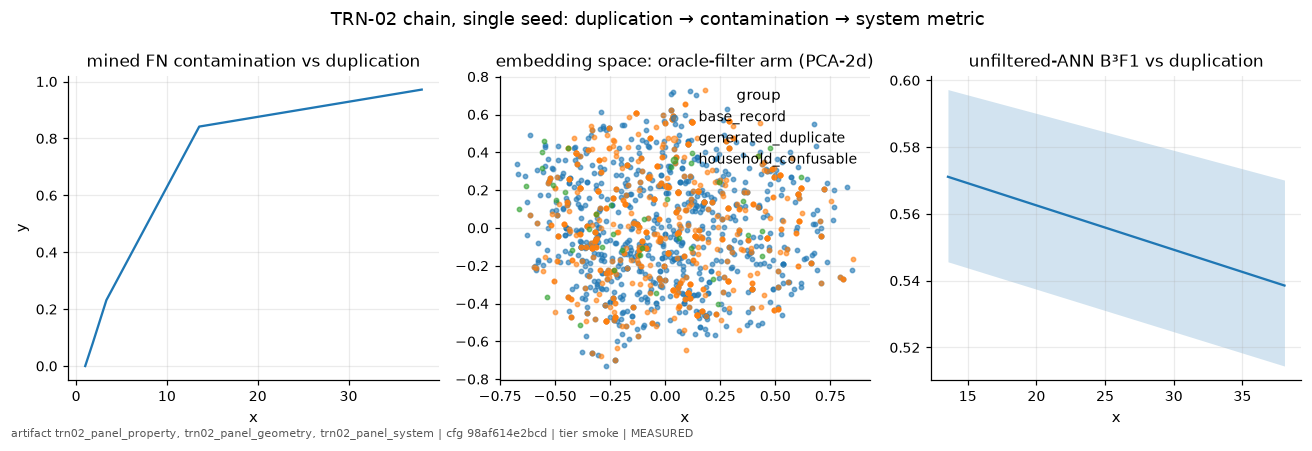

In [39]:
prop2 = (dial_df[dial_df["miner"] == "ann_frozen_encoder"]
         [["mean_cluster_size", "contamination"]]
         .rename(columns={"mean_cluster_size": "x", "contamination": "y"}))
geo2_xy = pca2(arm_state["trn02/ann_filtered_oracle"]["encoder"]
               .encode(GEO_TEXTS, batch_size=ENC_BATCH))
geo2 = pd.DataFrame({"x": geo2_xy[:, 0], "y": geo2_xy[:, 1], "group": GEO_KIND})
sys2 = (trn02[trn02["arm"].isin(["ann", "ann_highdup"])]
        [["mean_cluster_size", "f1", "f1_lo", "f1_hi"]]
        .rename(columns={"mean_cluster_size": "x", "f1": "y", "f1_lo": "lo",
                         "f1_hi": "hi"}))
registry.register("trn02_panel_property", prop2, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-02 triptych left: raw mined FN contamination vs "
                                "residual duplication (frozen-encoder dial)"})
registry.register("trn02_panel_geometry", geo2, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-02 triptych middle: PCA-2d of the oracle-filter "
                                "arm's eval-sample embeddings by record kind"})
registry.register("trn02_panel_system", sys2, cfg=cfg, tier=cfg.run.tier,
                  meta={"note": "TRN-02 triptych right: unfiltered-ANN B3F1 at natural "
                                "vs boosted duplication (the filter arm's recovery is "
                                "the ledger's story)"})
fig = figures.three_panel_pressure(
    registry, tier=cfg.run.tier,
    property_shift="trn02_panel_property", geometry="trn02_panel_geometry",
    system_metric="trn02_panel_system",
    titles=("mined FN contamination vs duplication",
            "embedding space: oracle-filter arm (PCA-2d)",
            "unfiltered-ANN B³F1 vs duplication"),
    suptitle="TRN-02 chain, single seed: duplication → contamination → system metric",
)

In [40]:
# [RUN-IN-TARGET node] definitive TRN-02: the locked 12-cell grid (4 miners x 3 residual-
# duplication levels, pretrained-subword regime, scratch-char spot-check) x replicates
# from met04_power_table, with the proxy-filter arm at every level.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: rows above are definitive-tier cells; the full grid runs on the "
          "node with replicates from met04_power_table at this tier.")
else:
    n_star = sn[0.02]
    trained = trn02[trn02["train_secs"].notna()]
    per_arm2 = float(trained["train_secs"].mean())
    runs2 = 12 * n_star
    est2_h = runs2 * per_arm2 * (STEPS_BY_TIER["target"] / STEPS) / 3600
    print(f"[RUN-IN-TARGET node] definitive TRN-02 = 12 cells x n*={n_star} replicates "
          f"= {runs2} runs (+ proxy arms). Measured mean mined-arm cost here: "
          f"{per_arm2:.0f}s at {STEPS} steps -> ~{est2_h:.0f} container-hours naive at "
          f"{STEPS_BY_TIER['target']} steps; TRN-02 is the top protected arm in PLAN §3's "
          "pruning order, so it survives any budget cut the power table forces.")

[RUN-IN-TARGET node] definitive TRN-02 = 12 cells x n*=2 replicates = 24 runs (+ proxy arms). Measured mean mined-arm cost here: 43s at 250 steps -> ~5 container-hours naive at 4000 steps; TRN-02 is the top protected arm in PLAN §3's pruning order, so it survives any budget cut the power table forces.


### 5d. Verdict — the trap is measured; the rescue is read through the noise band

In [41]:
byarm = trn02.set_index("arm")
dial_ann = (dial_df[dial_df["miner"] == "ann_frozen_encoder"]
            .sort_values("mean_cluster_size"))
p1_monotone = bool(dial_ann["contamination"].is_monotonic_increasing)
f1_inb, f1_bm, f1_ann = (float(byarm.loc[a, "f1"]) for a in ("inbatch", "bm25", "ann"))
f1_orc = float(byarm.loc["ann_filtered_oracle", "f1"])
f1_sdx = float(byarm.loc["ann_filtered_soundex", "f1"])
mined_beats_inb = max(f1_bm, f1_ann) - f1_inb
p2_no_free_win = mined_beats_inb <= DETECT_BAR
p2_oracle_best_mined = f1_orc >= max(f1_bm, f1_ann, f1_sdx)
gap = f1_inb - f1_ann
recovery = (f1_orc - f1_ann) / gap if gap > 0 else float("nan")
p3_sig = (f1_orc - f1_ann) > DETECT_BAR
contradiction = (mined_beats_inb > DETECT_BAR) or ((f1_ann - f1_orc) > DETECT_BAR)
if not p1_monotone or contradiction:
    trn02_outcome = "REFUTED"
elif p1_monotone and p3_sig and p2_oracle_best_mined:
    trn02_outcome = "CONFIRMED"
else:
    trn02_outcome = "UNEXPLAINED"
print(f"P1 dial (frozen-encoder ANN contamination, by mean cluster size): "
      f"{[round(v, 3) for v in dial_ann['contamination']]} -> monotone: {p1_monotone}")
print(f"P2: mined-vs-inbatch best delta {mined_beats_inb:+.4f} (bar {DETECT_BAR:.4f}) -> "
      f"no free win: {p2_no_free_win}; oracle best mined arm: {p2_oracle_best_mined}")
rec_txt = f"{recovery:.2f}" if gap > 0 else "n/a (no gap)"
print(f"P3: inbatch-minus-ann gap {gap:+.4f}; oracle recovery {rec_txt} of the gap; "
      f"oracle-minus-ann {f1_orc - f1_ann:+.4f} "
      f"{'EXCEEDS' if p3_sig else 'inside'} the bar")
print(f"proxy demo: soundex F1 {f1_sdx:.4f} vs oracle {f1_orc:.4f} "
      f"(gap {f1_orc - f1_sdx:+.4f}); post-filter contamination oracle "
      f"{byarm.loc['ann_filtered_oracle', 'post_filter_contamination']:.3f} vs proxy "
      f"{byarm.loc['ann_filtered_soundex', 'post_filter_contamination']:.3f}; keep-rates "
      f"{byarm.loc['ann_filtered_oracle', 'filter_keep_rate']:.2%} / "
      f"{byarm.loc['ann_filtered_soundex', 'filter_keep_rate']:.2%}")

_ = verdict_box(
    "TRN-02",
    outcome=trn02_outcome,
    evidence=(
        f"trn02_miner_matrix + trn02_contamination_dial (tier {TIER}, 1 seed, "
        f"{int(trn02['steps'].iloc[0])} matched steps). P1 {p1_monotone}: raw mined "
        f"contamination rises {dial_ann['contamination'].iloc[0]:.3f} -> "
        f"{dial_ann['contamination'].iloc[-1]:.3f} across mean cluster size "
        f"{dial_ann['mean_cluster_size'].iloc[0]:.1f} -> "
        f"{dial_ann['mean_cluster_size'].iloc[-1]:.1f} — the dose-response is a direct "
        f"measurement, not a seed-limited comparison. P2: best mined-arm-minus-inbatch "
        f"delta {mined_beats_inb:+.4f} vs bar {DETECT_BAR:.4f} (no significant free win: "
        f"{p2_no_free_win}); oracle filter best mined arm: {p2_oracle_best_mined}. "
        f"P3: oracle-minus-ANN {f1_orc - f1_ann:+.4f} "
        f"{'clears' if p3_sig else 'sits inside'} the MET-04 bar"
        + (f" (recovery {recovery:.2f} of the in-batch gap)" if gap > 0 else
           " (no in-batch-minus-ANN gap to recover at this seed)")
        + f". Proxy demo: soundex keeps {byarm.loc['ann_filtered_soundex', 'filter_keep_rate']:.0%} "
        f"of mined pairs (oracle {byarm.loc['ann_filtered_oracle', 'filter_keep_rate']:.0%}) "
        f"and cuts post-filter contamination to "
        f"{byarm.loc['ann_filtered_soundex', 'post_filter_contamination']:.3f} "
        f"(oracle {byarm.loc['ann_filtered_oracle', 'post_filter_contamination']:.3f}); "
        f"oracle-vs-proxy F1 gap {f1_orc - f1_sdx:+.4f}. System-metric claims at one "
        f"seed are read through the pre-registered noise rule; the definitive 12-cell "
        f"multi-seed grid is tier=node (placard above). Mediation duplication -> "
        f"contamination -> F1: UNEXPLAINED at one seed, and not claimed."
    ),
    registry=registry,
)

P1 dial (frozen-encoder ANN contamination, by mean cluster size): [0.0, 0.08, 0.232, 0.842, 0.972] -> monotone: True
P2: mined-vs-inbatch best delta +0.0037 (bar 0.0224) -> no free win: True; oracle best mined arm: True
P3: inbatch-minus-ann gap -0.0037; oracle recovery n/a (no gap) of the gap; oracle-minus-ann +0.0223 inside the bar
proxy demo: soundex F1 0.5917 vs oracle 0.5935 (gap +0.0018); post-filter contamination oracle 0.000 vs proxy 0.444; keep-rates 15.90% / 28.22%


> ### VERDICT: UNEXPLAINED — card `TRN-02`
>
> **Conjecture** Hard-negative mining in a dedup-dense corpus poisons itself: the harder the miner works, the more of its 'negatives' are unlabeled true duplicates (false negatives), the more so the higher the residual duplication — and a cluster-aware filter that drops mined pairs co-clustered by a truth proxy recovers most of what contamination costs.
>
> **Prediction** P1: raw mined contamination rises monotonically with residual duplication (per-entity-cap dial through the natural corpus up to the boosted variant). P2: at natural duplication the unfiltered mined arms do not beat in-batch, and the oracle filter arm is the best mined arm. P3: the oracle filter recovers at least half of the in-batch-minus-ANN gap where that gap exists; the soundex proxy keeps most of the oracle's recovery while over-filtering some clean negatives. Decision rule: P1 is scored on the measured dial directly; P2/P3 system-metric claims are scored only beyond the MET-04 bar 2*sqrt(2)*sd_replicate — inside the bar they are noise-bound (UNEXPLAINED), which at one smoke seed is the expected outcome.
>
> **Evidence** trn02_miner_matrix + trn02_contamination_dial (tier smoke, 1 seed, 250 matched steps). P1 True: raw mined contamination rises 0.000 -> 0.972 across mean cluster size 1.0 -> 38.1 — the dose-response is a direct measurement, not a seed-limited comparison. P2: best mined-arm-minus-inbatch delta +0.0037 vs bar 0.0224 (no significant free win: True); oracle filter best mined arm: True. P3: oracle-minus-ANN +0.0223 sits inside the MET-04 bar (no in-batch-minus-ANN gap to recover at this seed). Proxy demo: soundex keeps 28% of mined pairs (oracle 16%) and cuts post-filter contamination to 0.444 (oracle 0.000); oracle-vs-proxy F1 gap +0.0018. System-metric claims at one seed are read through the pre-registered noise rule; the definitive 12-cell multi-seed grid is tier=node (placard above). Mediation duplication -> contamination -> F1: UNEXPLAINED at one seed, and not claimed.


## 6. What the pressure notebooks inherit

- **`met04_power_table` is now in force.** Notebook 10 (TRN-03/04) requires it by DAG
  contract; every mid/node matrix sizes replicates from `seeds_needed` or invokes the
  pre-registered §10.1 fractionalization rule. The smoke-scope flag travels in the
  artifact meta, and the mid-tier rerun shadows this table at its own tier.
- **The single-seed detectability bar is the reading lens for every smoke matrix.** Both
  verdicts above applied it; notebooks 10–11 should quote the same bar rather than
  invent their own. A smoke row is a demonstration; the bar is what keeps it honest.
- **`trn01_loss_matrix` seeds the loss factor.** Notebook 12 consumes it by contract
  (blocking experiments need a trained encoder's embeddings); the node factorial fills
  the pretrained regime and the replicate axis.
- **`trn02_miner_matrix` + `trn02_contamination_dial` are the FN-contamination
  evidence.** The dial is the mechanism figure; the matrix carries the mitigation
  accounting (post-filter contamination, keep-rates, the oracle-vs-proxy gap) that
  HYB-01's rules ledger and the TRN-02 node grid build on. TRN-02 is the top protected
  arm in the pruning order — if compute forces cuts, this is the last training question
  standing.

**Artifacts registered** (exact names): `met04_power_table`, `trn01_loss_matrix`,
`trn02_miner_matrix` — plus supporting `met04_pilot_runs`, `trn02_contamination_dial`,
the six triptych panels (`trn01_panel_*`, `trn02_panel_*`), and immutable cards
`card_MET-04`, `card_TRN-01`, `card_TRN-02`.

In [42]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 min"
      + ("" if total <= 2100 else "  <-- OVER BUDGET at this run; see section table"))

,section,secs
0,§1 arena + shared recipe,0.0
1,§1b property instruments,38.0
2,§3a pilot corpora,0.0
3,§3b pilot runs,264.0
4,§3c decomposition + power table,0.0
5,§4a TRN-01 scratch arms,212.0
6,§4b pretrained gate,0.0
7,§5a boosted corpus + in-batch simulation,0.0
8,§5b miner arms,195.0
9,§5c proxy arm + filter accounting,51.0


notebook wall-clock: 772s (12.9 min) — smoke budget <= ~30 min
